# Intel Xe / Xe4 / Xe5 Atoms — Layout Transformations on the CPU

This notebook emulates the **MMA and Copy atoms** of the Intel Xe GPU family
(as defined in the sycl-tla / CUTLASS-Xe headers) in pure Python, and *shows
the layout transformations* — no GPU required.

Each atom is a set of **(thread, value) → element** maps (`a_layout`,
`b_layout`, `c_layout` for MMA; `src_layout_bits`, `dst_layout_bits` for Copy),
exactly mirroring the C++ `MMA_Traits<>` / `Copy_Traits<>` structs.  Because a
`Layout` is just a callable `L(t, v) -> offset`, we can execute and draw them.

Three families:

| Family | Subgroup | Highlights |
|--------|----------|------------|
| **Xe** (legacy Xe-HPC/HPG) | 16 lanes | `XE_DPAS_TT` (VNNI work-item interleave), 1D/2D block copies |
| **Xe4** | 32 lanes | `XE4_TMM` (register), `XE4_AMMA` (SLM descriptor), ADMA/LDSM/EU copies |
| **Xe5** | 32 lanes | single-group + **dual-group** AMMA, LARGE, block-scaled MX (fp6) |


In [1]:
%matplotlib inline
import matplotlib
from tensor_layouts import Layout, size
from tensor_layouts.analysis import atom_summary, is_bijective
from tensor_layouts.viz import draw_mma_layout, draw_copy_atom, draw_layout

import tensor_layouts.atoms_xe  as xe
import tensor_layouts.atoms_xe4 as xe4
import tensor_layouts.atoms_xe5 as xe5
from tensor_layouts.atoms_xe_common import (
    wi_interleave, make_slm_layout_elem, make_ordered_layout, sizeof_bits,
)
print("Xe  MMA:", len(xe.MMA_ATOMS_XE),  " Copy:", len(xe.COPY_ATOMS_XE))
print("Xe4 MMA:", len(xe4.MMA_ATOMS_XE4)," Copy:", len(xe4.COPY_ATOMS_XE4))
print("Xe5 MMA:", len(xe5.MMA_ATOMS_XE5)," Copy:", len(xe5.COPY_ATOMS_XE5))


Xe  MMA: 19  Copy: 11
Xe4 MMA: 20  Copy: 25
Xe5 MMA: 25  Copy: 9


## 1. Legacy Xe — the DPAS systolic MMA (`XE_DPAS_TT`)

On Xe the subgroup is **16 lanes** and the DPAS shape is `M × 16 × K`, with
`K = 256 / max(bits(A), bits(B))` (so K=16 for bf16/fp16, 8 for tf32, 32 for
int8, 64 for int4).  The accumulator C is `(16, M):(M, 1)` — lane *t* owns
column *t*, value *v* selects row *v*.


In [2]:
dpas = xe.XE_DPAS_8x16x16_F32BF16BF16F32
print("shape MNK:", dpas.shape_mnk)
print("A:", dpas.a_layout)
print("B:", dpas.b_layout)
print("C:", dpas.c_layout)
atom_summary(dpas);


shape MNK: (8, 16, 16)
A: (16, 8) : (8, 1)
B: ((2, 8), (2, 8)) : ((16, 1), (8, 32))
C: (16, 8) : (8, 1)
XE_DPAS_8x16x16_F32BF16BF16F32
  Shape (M, N, K): 8 x 16 x 16
  Threads:          16
  Values per thread: A=8, B=16, C=8
  C covers M*N:     True


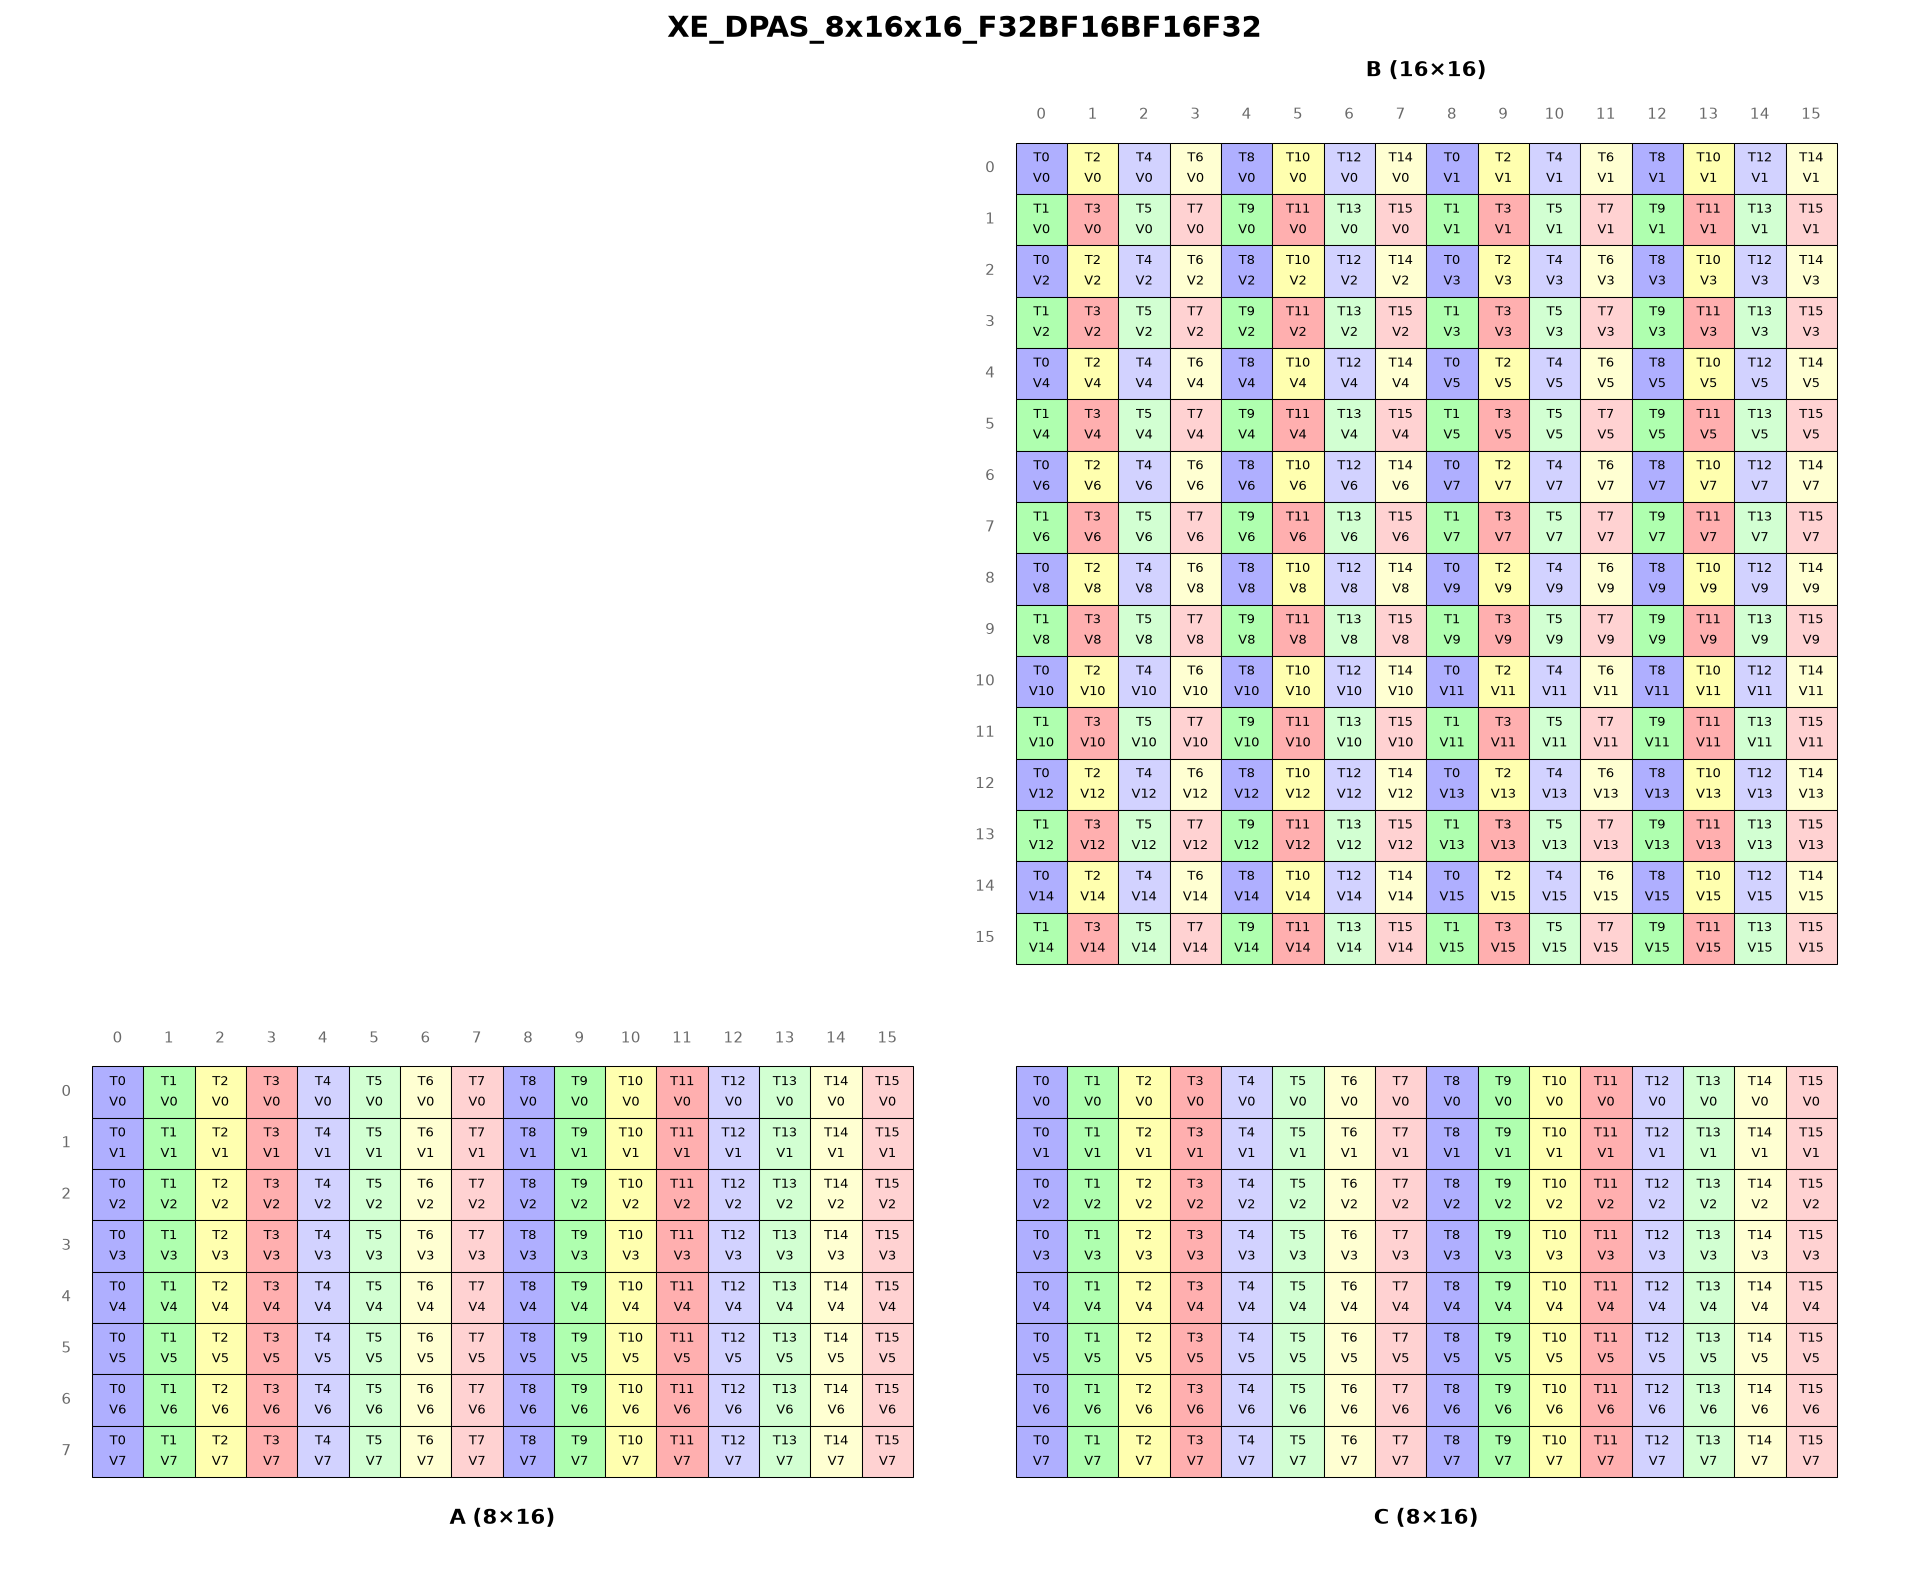

In [3]:
draw_mma_layout(dpas.a_layout, dpas.b_layout, dpas.c_layout,
                tile_mnk=dpas.shape_mnk, main_title=dpas.name,
                thr_id_layout=dpas.thr_id)


### The work-item (VNNI) interleave — `detail::wi_interleave`

The A/B operands are not laid out naively: values are **interleaved across the
16 work-items** so each lane holds a contiguous register fragment.  This is the
`wi_interleave` transform — `coalesce(compose(base, tv), Step<_1,_1>)`.

Below: the *base* `(K, M)` layout vs. the *interleaved* A layout.  The
interleave is a permutation of the same 128 elements.


base    : (16, 8) : (8, 1)
wi_inter: (16, 8) : (8, 1)  (thread stride, value stride)
same element set?  True


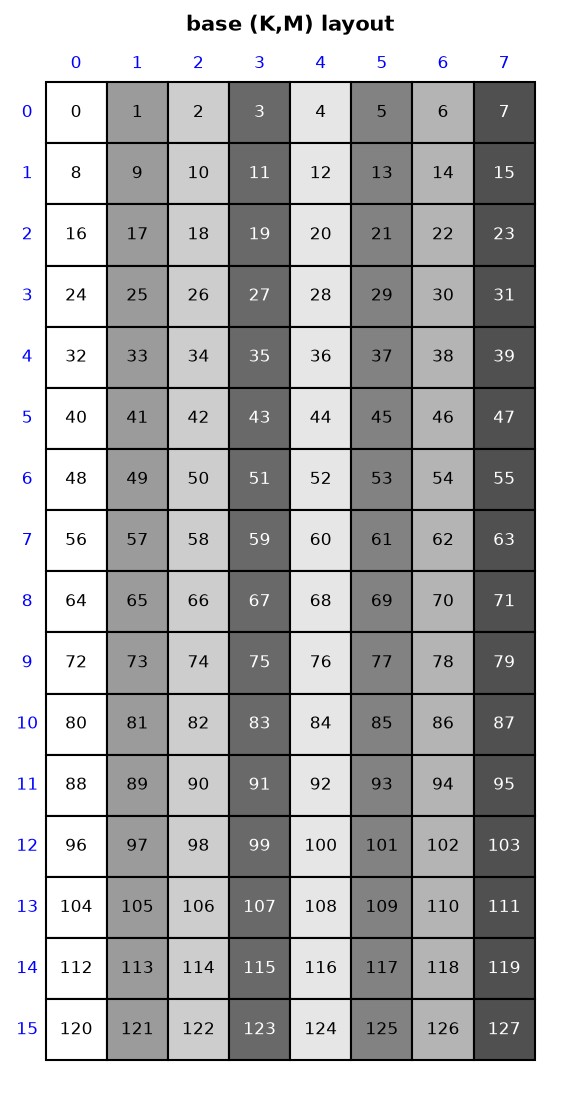

In [4]:
base = Layout((16, 8), (8, 1))            # (K=16, M=8) row-major
inter = wi_interleave(16, base, sg_size=16) # bf16 A layout
print("base    :", base)
print("wi_inter:", inter, " (thread stride, value stride)")
print("same element set? ",
      {inter(t, v) for t in range(16) for v in range(8)} == set(range(128)))
draw_layout(base, title="base (K,M) layout")


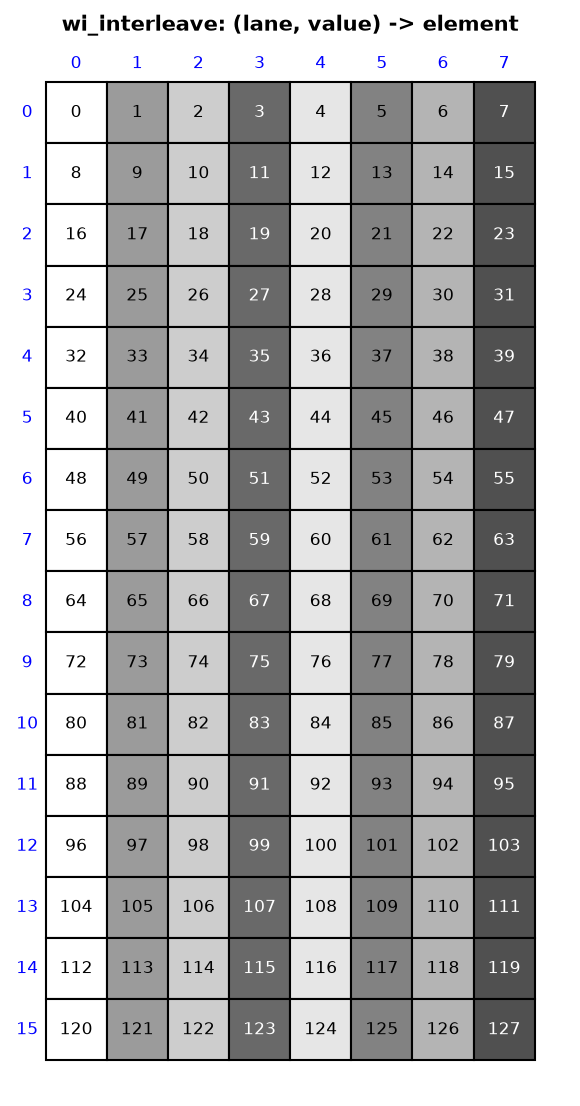

In [5]:
draw_layout(inter, title="wi_interleave: (lane, value) -> element")


## 2. Xe 2D block copy + `XeInterleavedLayout`

The 2D block copies (`XE_LOAD_2D`, `XE_STORE_2D`, transpose, prefetch) split a
subgroup tile into a (thread, value) layout **in bit coordinates** using
`XeInterleavedLayout`.  For a load, the *source* broadcasts across the 16 lanes
(stride 0 on the thread mode) and the *destination* is the interleaved
register tile.


XE_LOAD_2D_16b_16x16
src bits (broadcast over 16 lanes): (16, (16, 16)) : (0, (1, 256))
dst bits (interleaved reg tile)    : (16, (16, 16)) : (16, (1, 256))
src thread stride == 0 (broadcast)? True


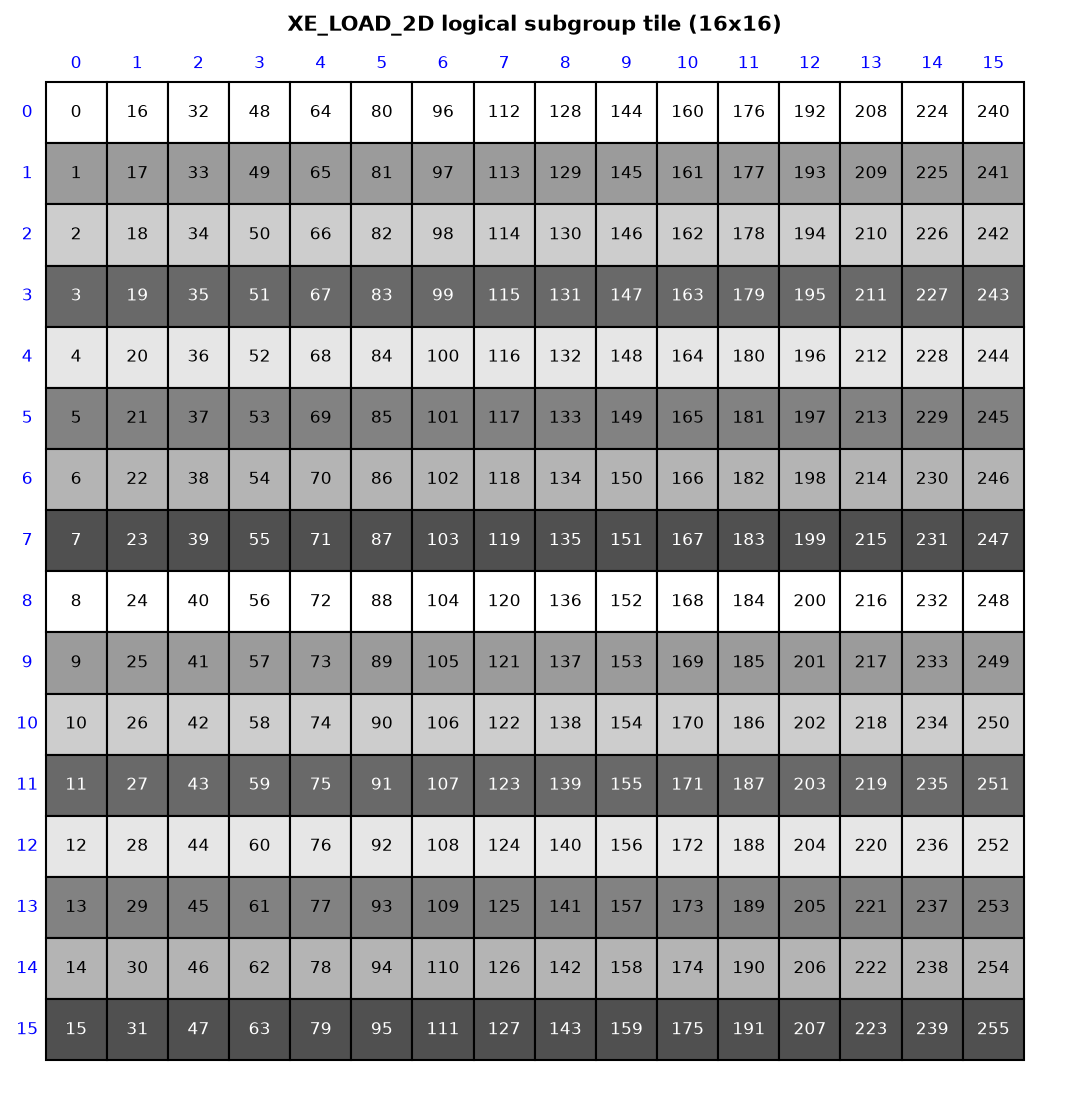

In [6]:
ld2d = xe.XE_LOAD_2D_16b_16x16
print(ld2d.name)
print("src bits (broadcast over 16 lanes):", ld2d.src_layout_bits)
print("dst bits (interleaved reg tile)    :", ld2d.dst_layout_bits)
# The source broadcasts: thread-mode stride is 0 (every lane sees the tile).
print("src thread stride == 0 (broadcast)?", ld2d.src_layout_bits.stride[0] == 0)
draw_layout(Layout((16, 16), (1, 16)), title="XE_LOAD_2D logical subgroup tile (16x16)")


## 3. Xe4 — `XE4_TMM` register MMA (subgroup 32)

TMM keeps operands in registers.  M is fixed at 32; lane *i* owns row *i* of
both A and C (`(M, K):(1, M)`).


XE4_TMM_32x32x16_F32BF16BF16F32 (32, 32, 16)


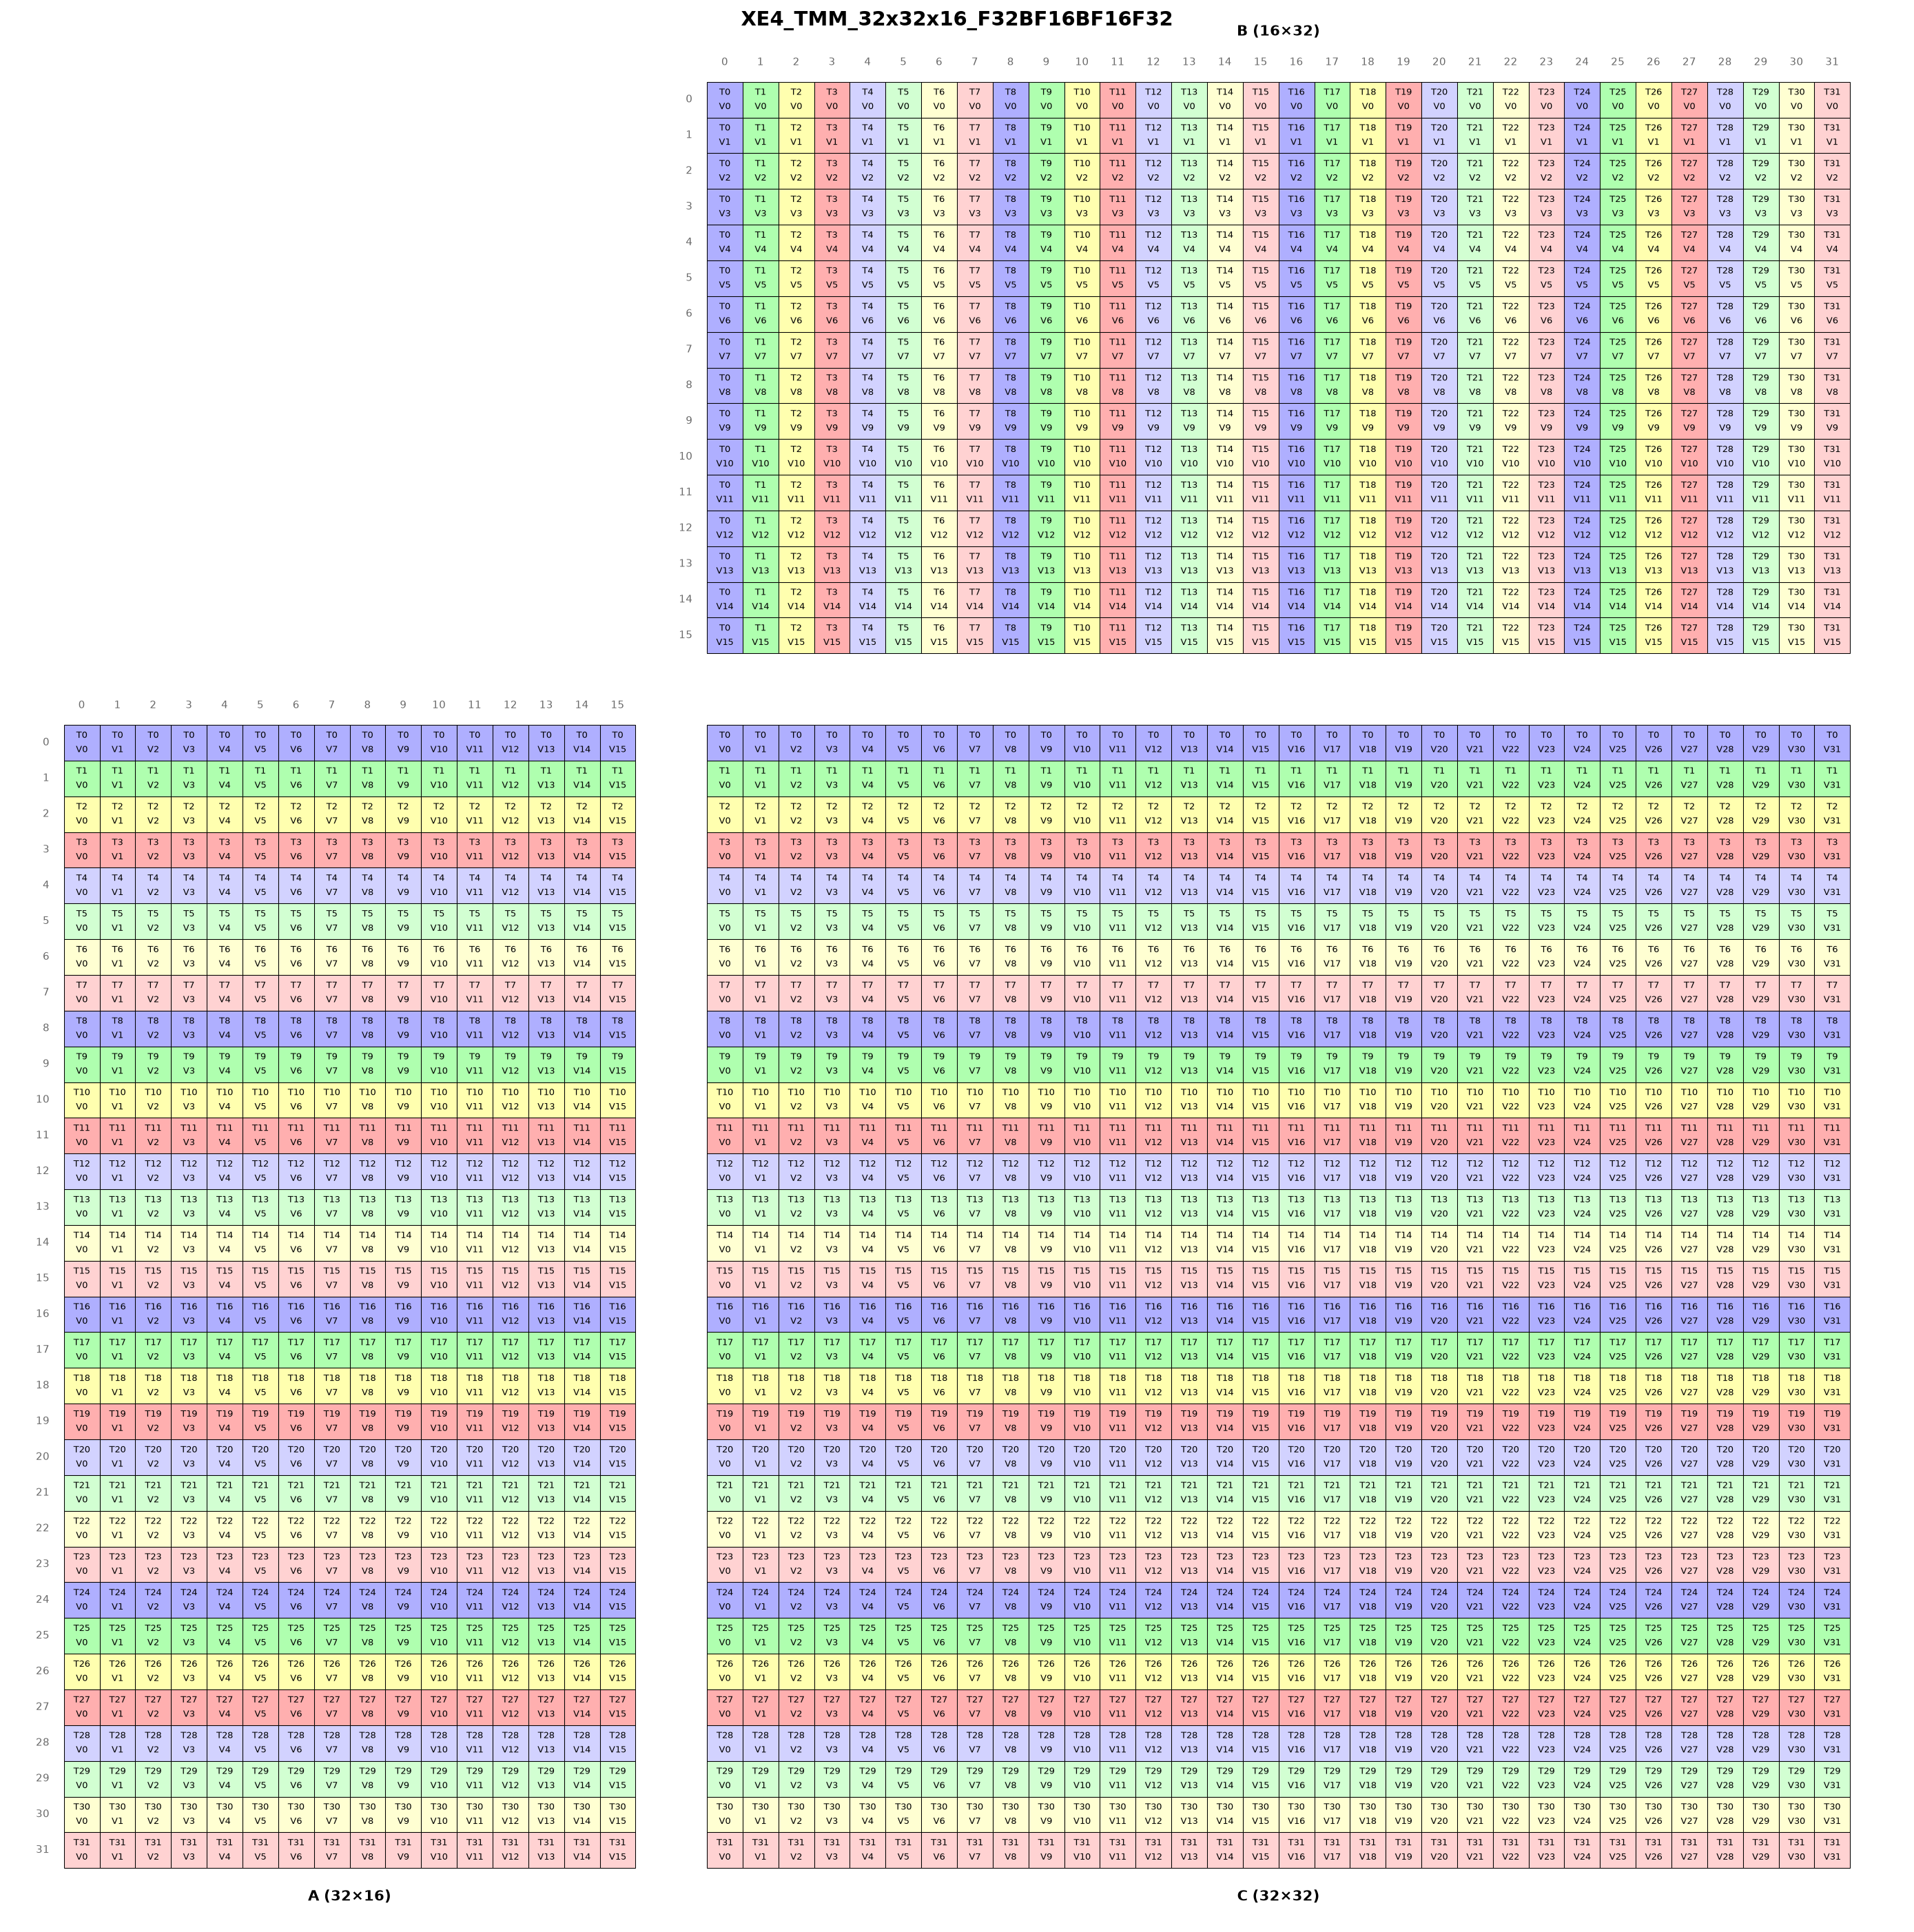

In [7]:
tmm = xe4.XE4_TMM_32x32x16_F32BF16BF16F32
print(tmm.name, tmm.shape_mnk)
draw_mma_layout(tmm.a_layout, tmm.b_layout, tmm.c_layout,
                tile_mnk=tmm.shape_mnk, main_title=tmm.name,
                thr_id_layout=tmm.thr_id)


## 4. Xe4 — `XE4_AMMA` and the SLM core-matrix layout

AMMA operands are **SLM matrix descriptors**.  In the traits the A/B/C layouts
are single-thread placeholders `(1, (M, K))` — the *real* data movement is the
**SLM core-matrix layout** that the descriptor points at.

Also note: the many barrier-tracking variants (None / GroupSync / D / DB / AB /
DAB / cluster …) all share the **same** A/B/C layout — tracking is a *type*
parameter, not a layout property.


In [8]:
base = xe4.MMA_ATOMS_XE4_AMMA[0]
print("descriptor A placeholder:", base.a_layout)
print("descriptor C placeholder:", base.c_layout)
print()
for a in xe4.MMA_ATOMS_XE4_AMMA:
    same = (a.a_layout == base.a_layout and a.c_layout == base.c_layout)
    print(f"  {a.name:52s} ptx={a.ptx:34s} same_layout={same}")


descriptor A placeholder: (1, (128, 32)) : (0, (1, 128))
descriptor C placeholder: (1, (128, 128)) : (0, (1, 128))

  XE4_AMMA_128x128x32_F32BF16BF16F32                   ptx=amma                               same_layout=True
  XE4_AMMA_GROUPSYNC_128x128x32_F32BF16BF16F32         ptx=amma.groupsync                     same_layout=True
  XE4_AMMA_D_128x128x32_F32BF16BF16F32                 ptx=amma.dtm                           same_layout=True
  XE4_AMMA_DB_128x128x32_F32BF16BF16F32                ptx=amma.dtm.btm                       same_layout=True
  XE4_AMMA_AB_128x128x32_F32BF16BF16F32                ptx=amma.atm.btm                       same_layout=True
  XE4_AMMA_DAB_128x128x32_F32BF16BF16F32               ptx=amma.dtm.atm.btm                   same_layout=True
  XE4_AMMA_AB_CLUSTER_128x128x32_F32BF16BF16F32        ptx=amma.atmm.btmm (cluster, a/b mask) same_layout=True
  XE4_AMMA_DB_CLUSTER_128x128x32_F32BF16BF16F32        ptx=amma.dtm.btmm (cluster, b mask)    same_layout=T

### The physical SLM tile (`make_slm_layout_elem`)

Each 1024-byte **core matrix** is `((2, 4, 4), cm_k) : ((32/e, 256/e, 64/e), 1)`
(e = bytes/element): 32 M-positions organised as (rows-per-tile=2, half-Esub
banks=4, MMA banks=4) × k.  The full M×K tile stacks core matrices.  It is a
**bijection** onto `[0, M·K)` — a bank-swizzled permutation of the logical
tile.


SLM A tile (128x32 bf16): ((2, 4, 4, 4), (16, 2)) : ((16, 128, 32, 1024), (1, 512))
size: 4096  bijective: True


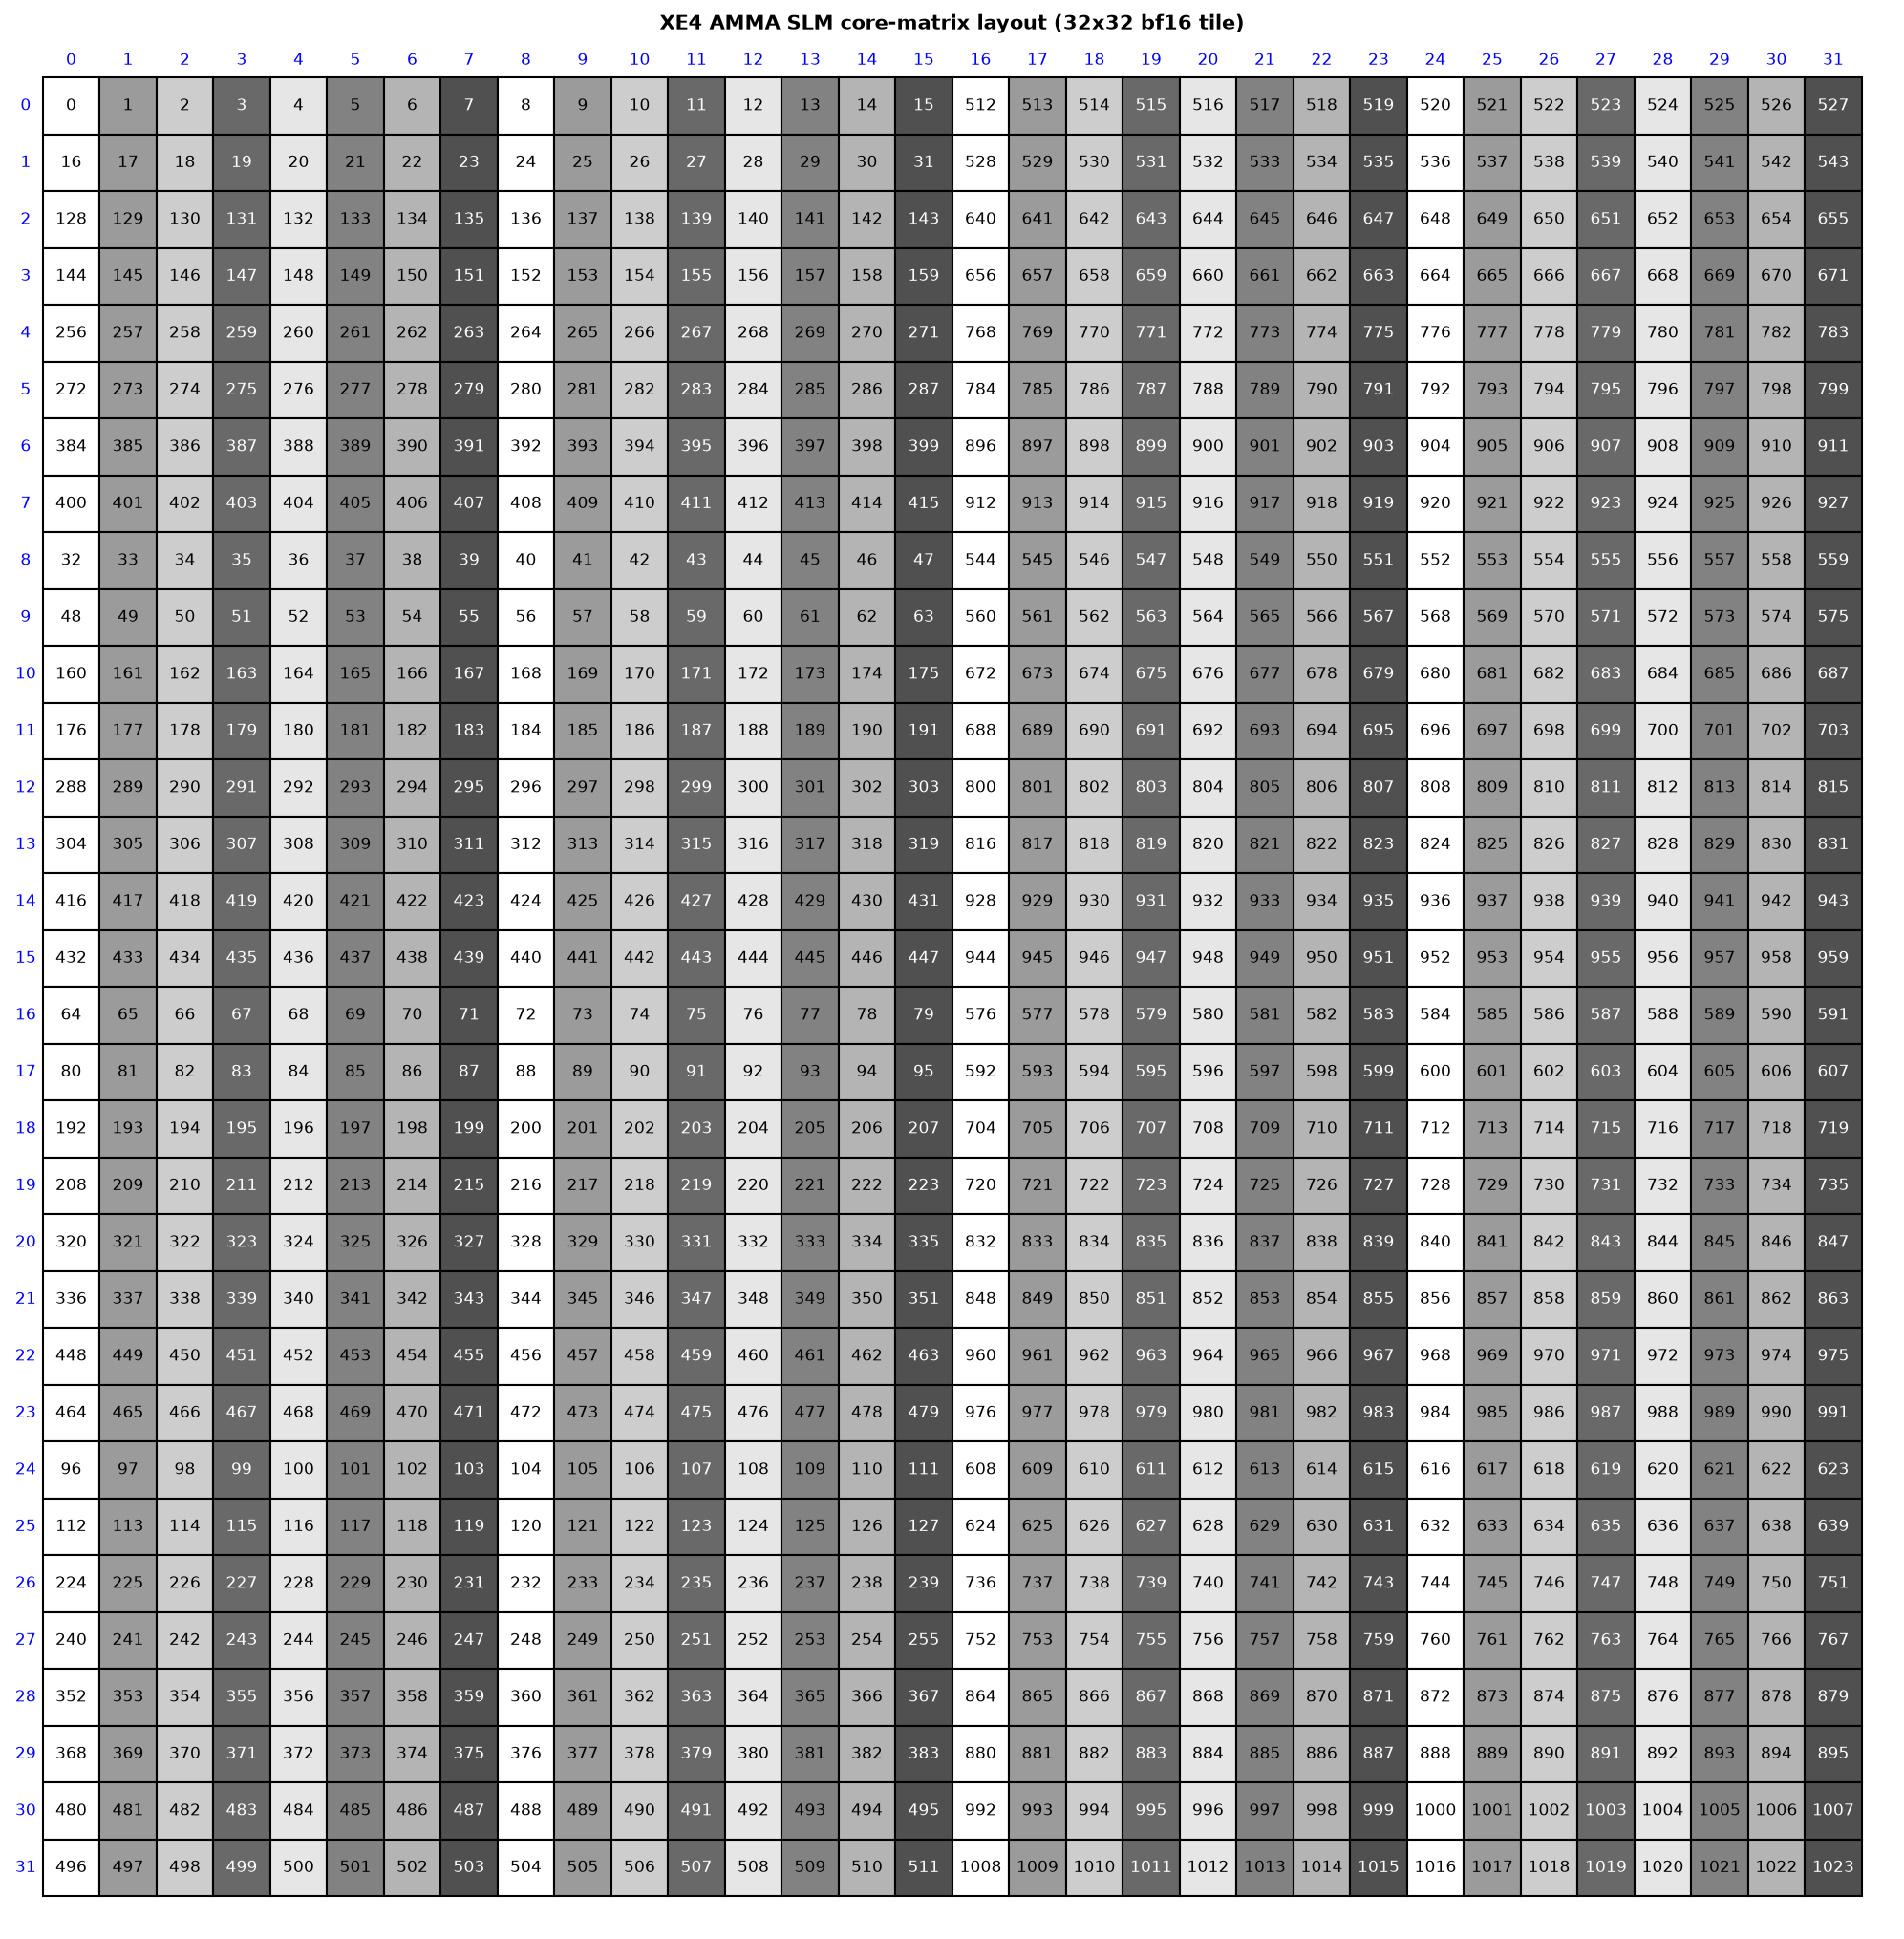

In [9]:
slm = make_slm_layout_elem(sizeof_bits('bf16'), 128, 32)  # A operand of the AMMA above
print("SLM A tile (128x32 bf16):", slm)
print("size:", size(slm), " bijective:", is_bijective(slm))
# Draw a smaller 32x32 core-matrix tile so the bank structure is legible.
slm_small = make_slm_layout_elem(sizeof_bits('bf16'), 32, 32)
draw_layout(slm_small, title="XE4 AMMA SLM core-matrix layout (32x32 bf16 tile)")


## 5. Xe4 — `XE4_EU_COPY_G2S`: the linear → SLM transformation

EU copies move a **linear (M×K row-major)** global tile into the **swizzled
SLM** core-matrix layout, running on the EU compute pipeline.  This is the most
visible transformation: the same element lands at a linear offset in gmem and a
*swizzled* offset in SLM.


element (m,k) :  linear_off -> slm_off
   ( 0, 0)     :    0      ->    0
   ( 0, 1)     :    1      ->    1
   ( 1, 0)     :   32      ->   16
   ( 2, 0)     :   64      ->  128
   ( 0,16)     :   16      ->  512
   (16, 0)     :  512      ->   64
   (31,31)     : 1023      -> 1023


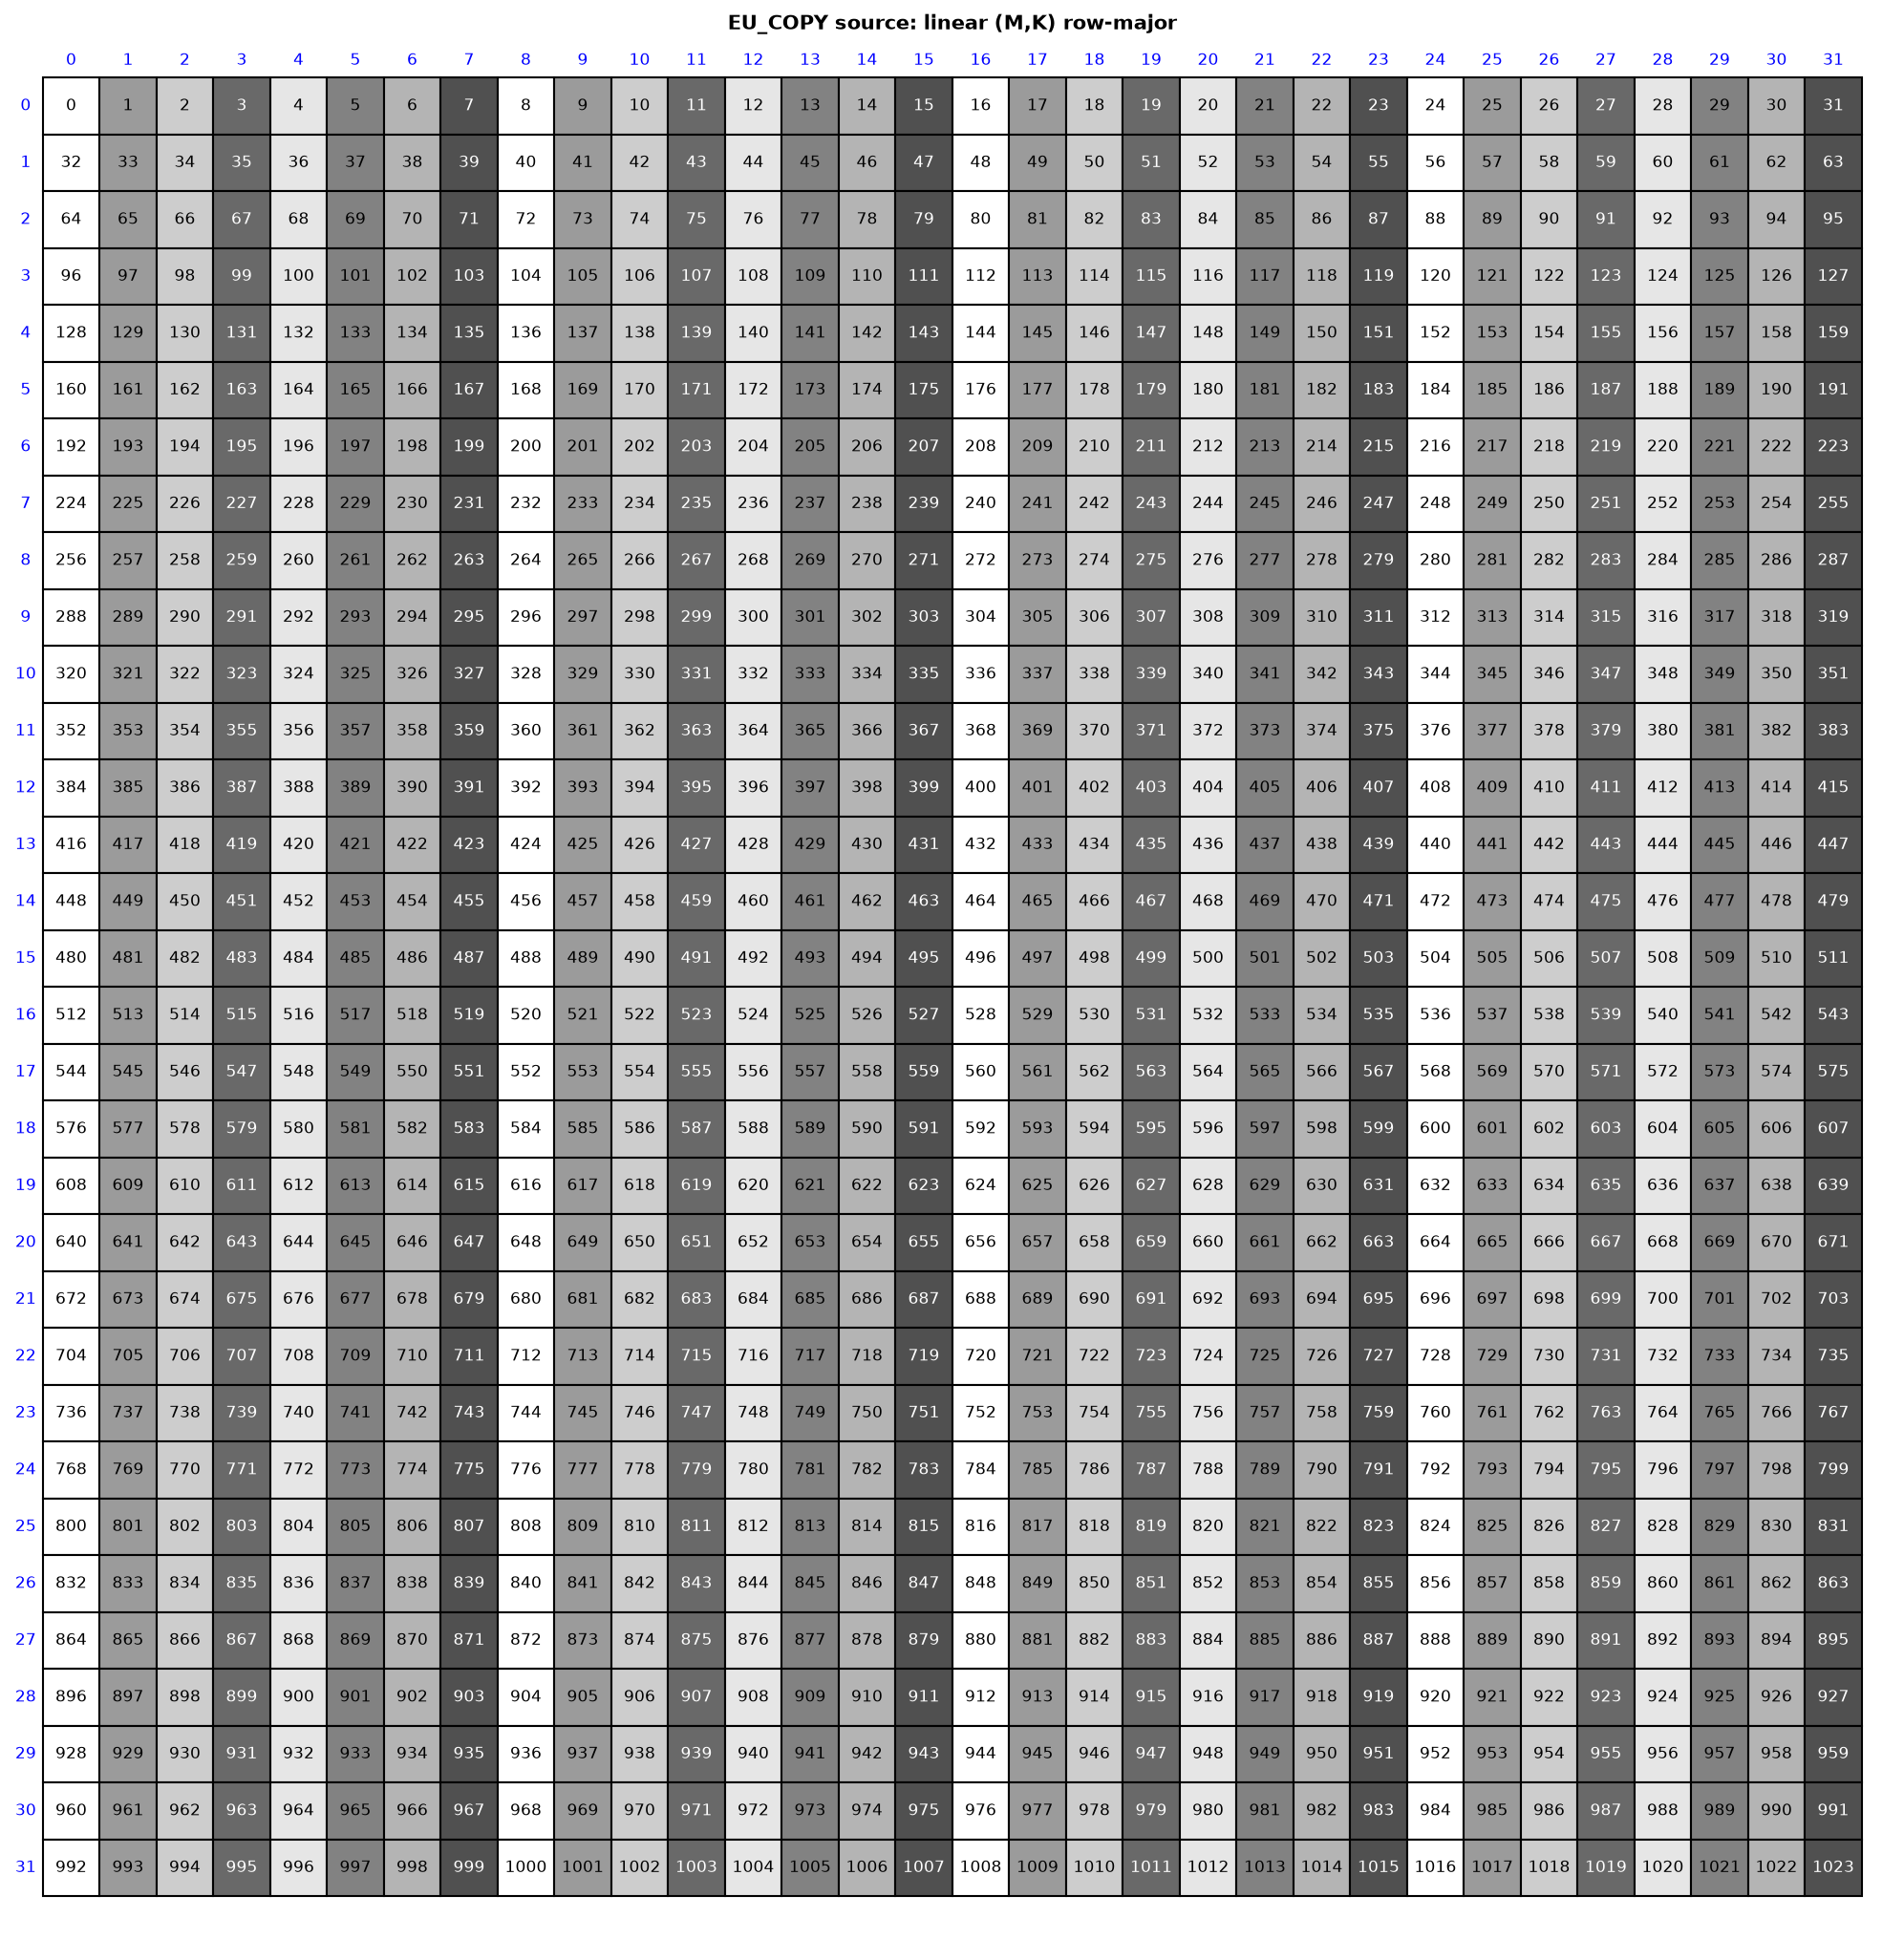

In [10]:
M, K = 32, 32
linear = Layout((M, K), (K, 1))             # row-major gmem tile
slm    = make_slm_layout_elem(16, M, K)     # swizzled SLM tile
print("element (m,k) :  linear_off -> slm_off")
for (m, k) in [(0,0),(0,1),(1,0),(2,0),(0,16),(16,0),(31,31)]:
    print(f"   ({m:2d},{k:2d})     : {linear(m,k):4d}      -> {slm(m,k):4d}")
draw_layout(linear, title="EU_COPY source: linear (M,K) row-major")


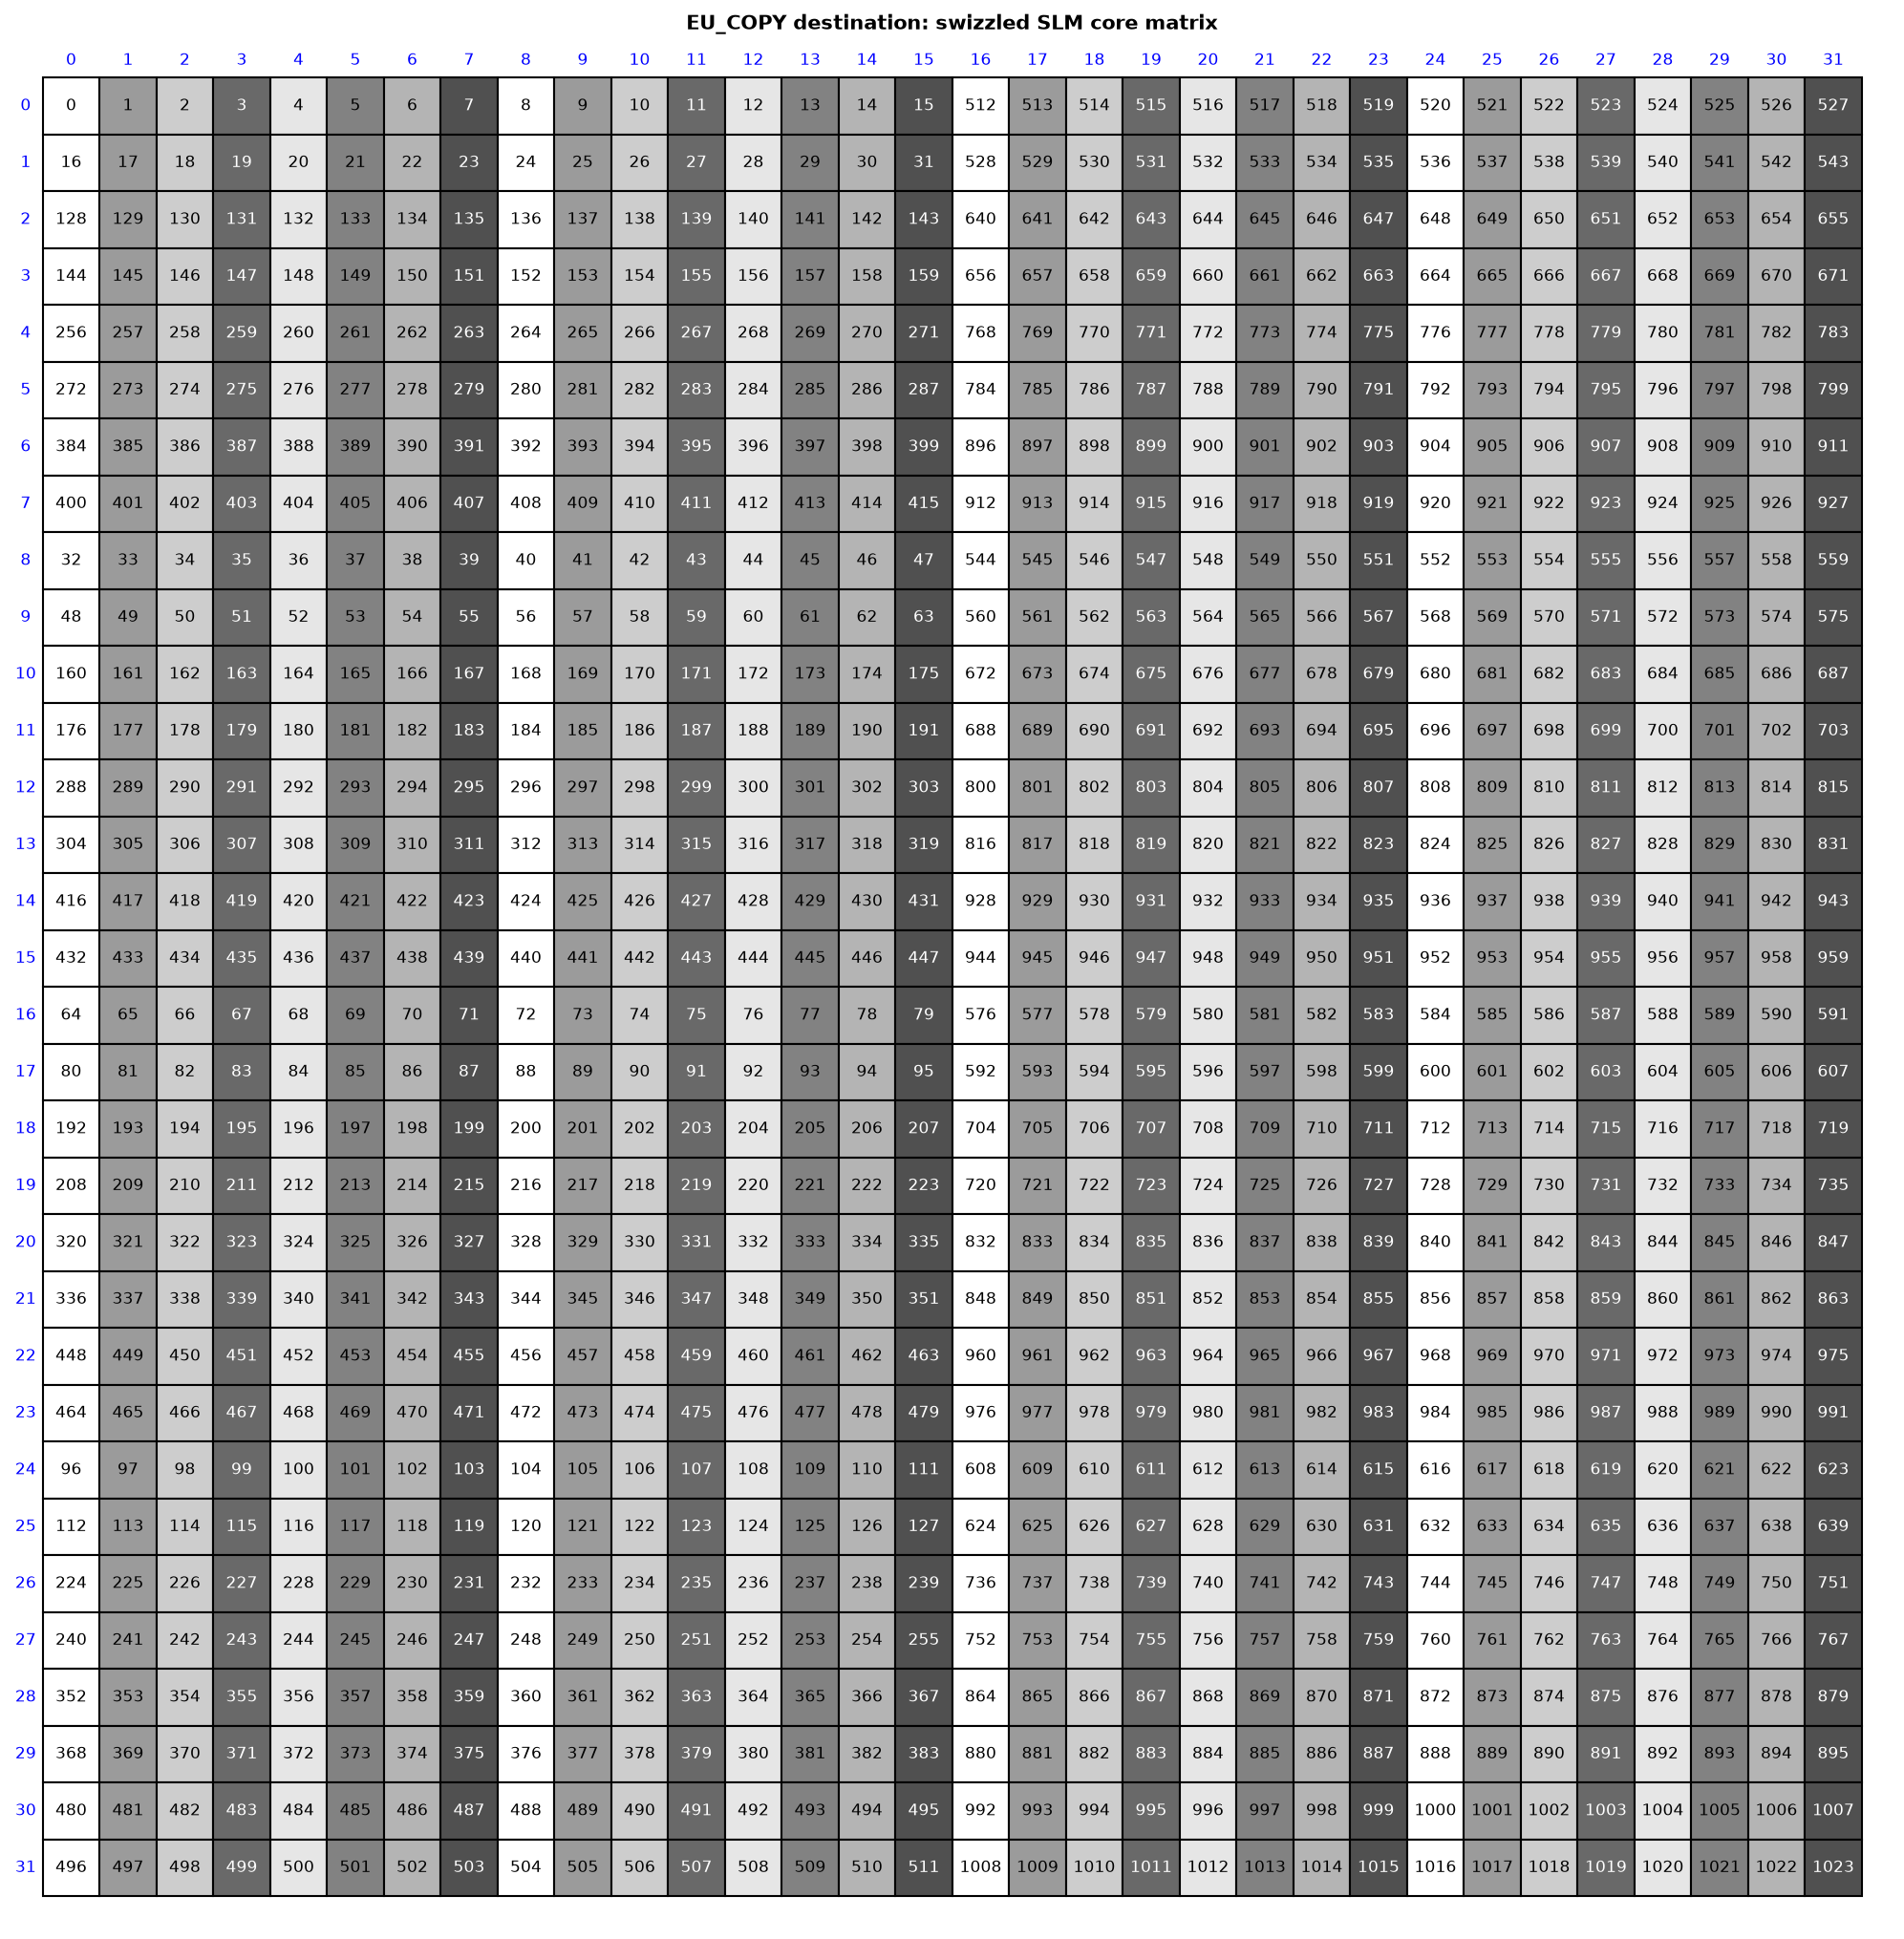

In [11]:
draw_layout(slm, title="EU_COPY destination: swizzled SLM core matrix")


## 6. Xe4 — `XE4_LDSM` warp copy (`make_ordered_layout`)

The SLM↔register LDSM/STSM copies use a 32-thread warp layout built by
`make_ordered_layout((32, (1, bits·VS)), Step<2,(1,0)>)`.


XE4_LDSM_VS8_BF16  src: (32, (1, 128)) : (128, (128, 1))


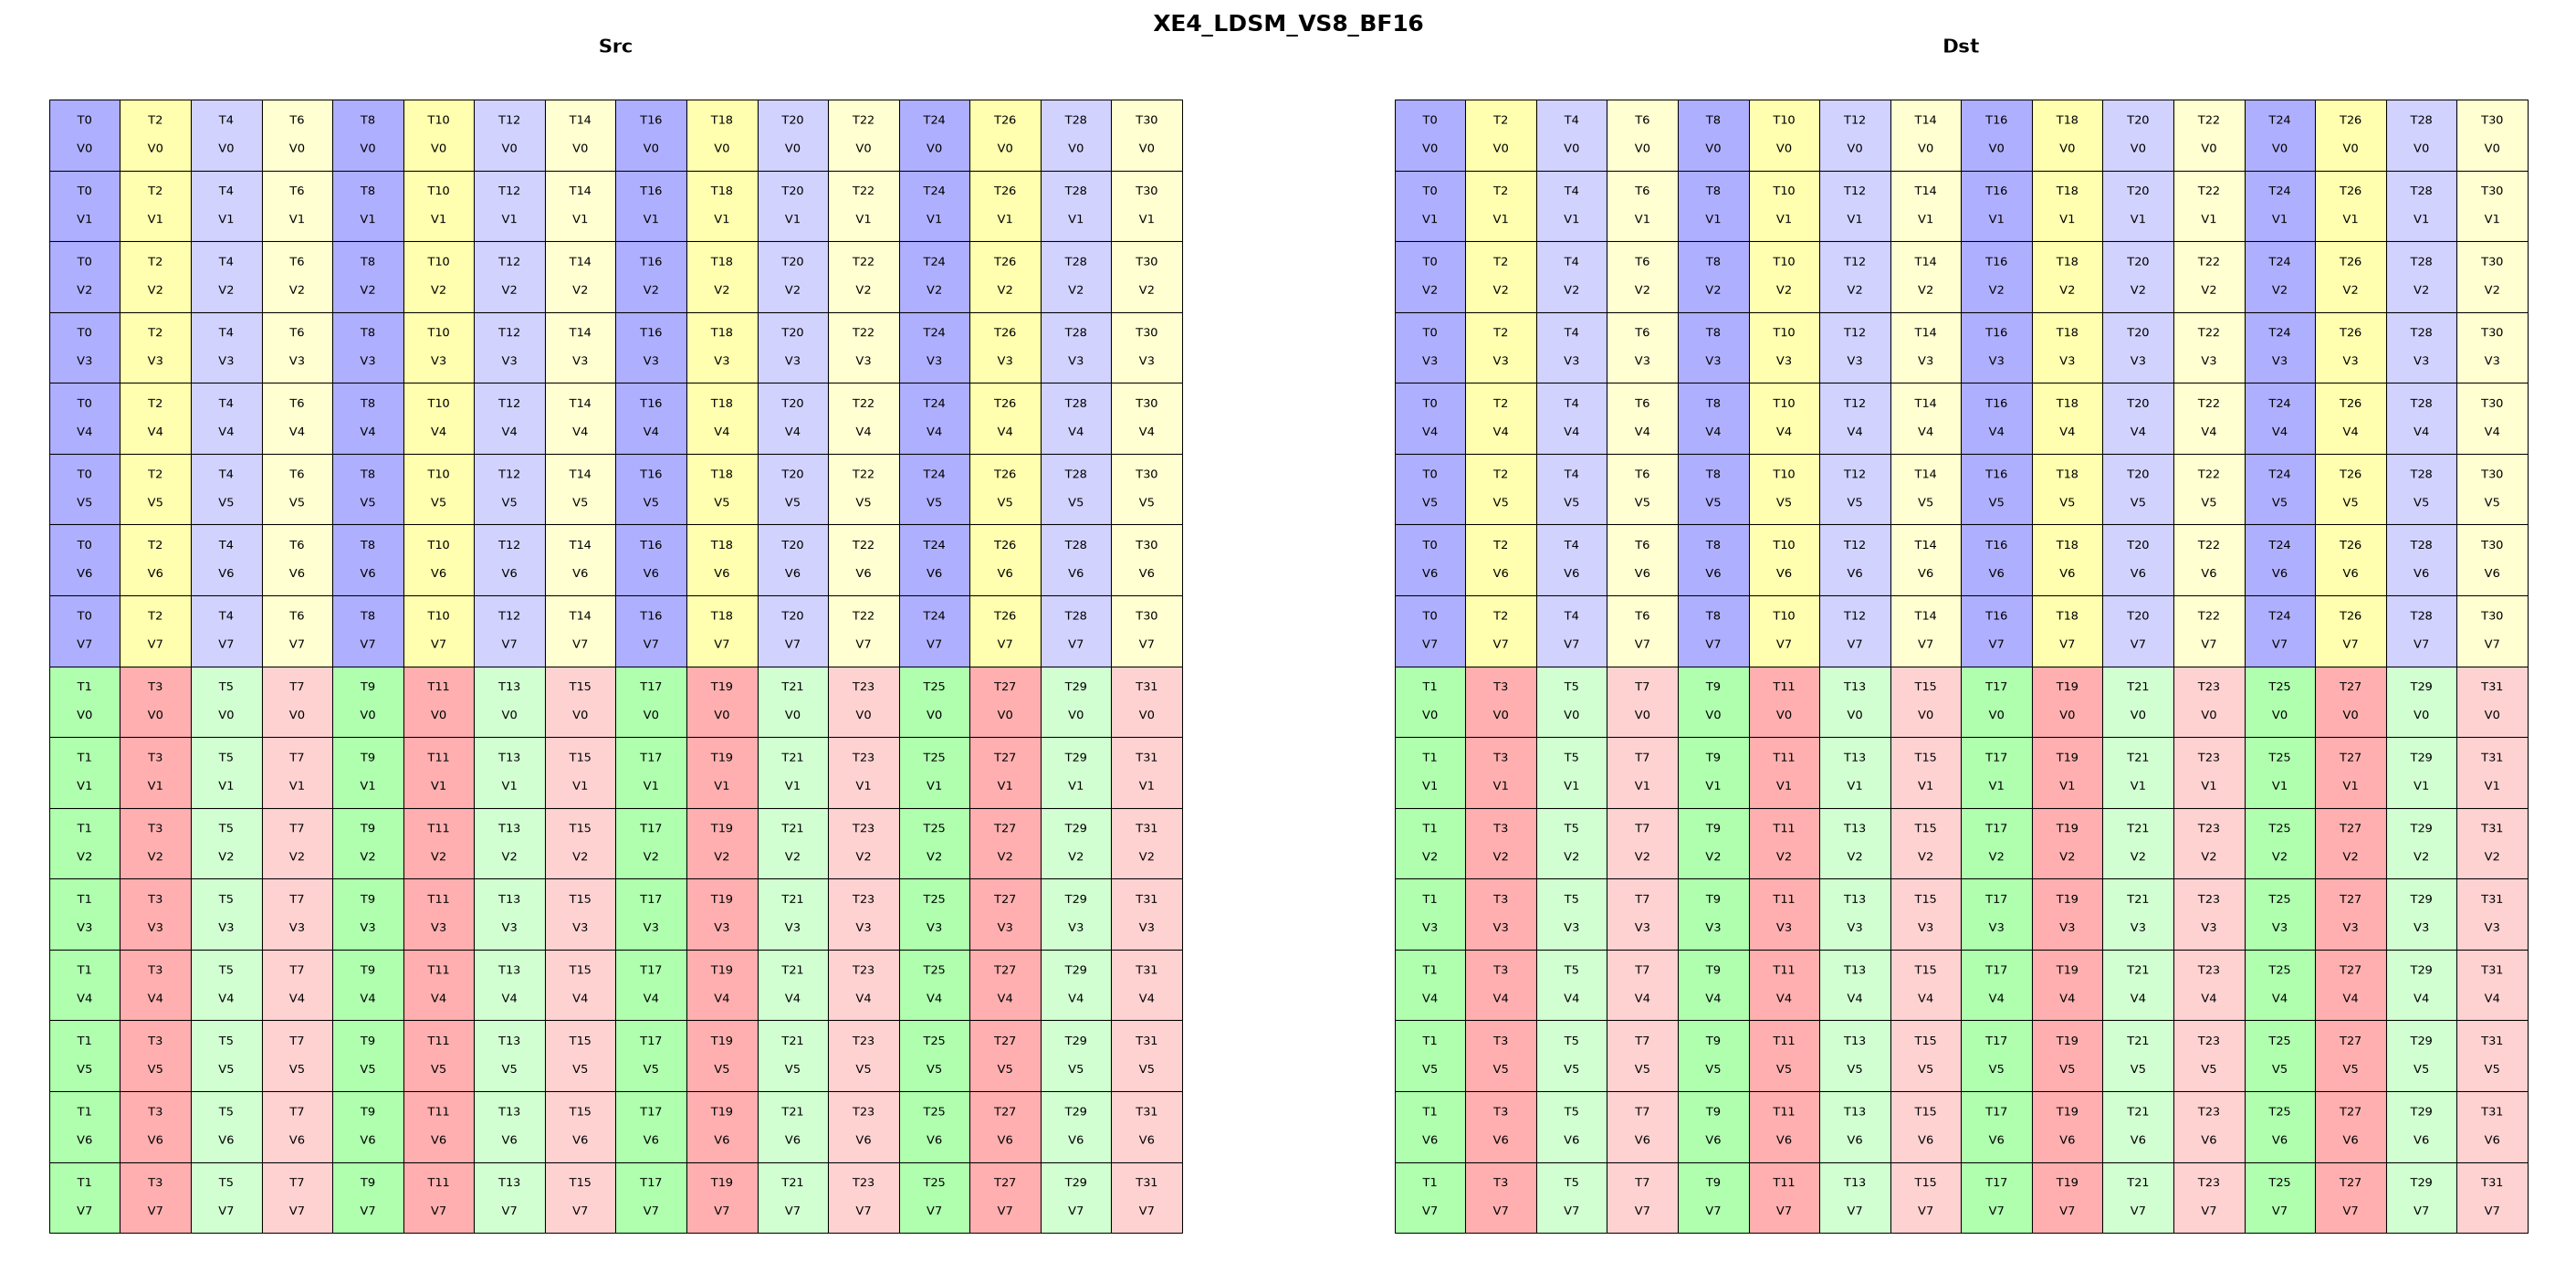

In [12]:
ldsm = xe4.XE4_LDSM_VS8_BF16
print(ldsm.name, " src:", ldsm.src_layout_bits)
draw_copy_atom(ldsm, element_bits=16, title=ldsm.name)


## 7. Xe5 — dual-group MMA

Xe5 adds **dual-group** atoms: a *lane pair* (ThrID = 2) splits M (and N) in
half — the SM100 "2×1SM" convention.  Compare the single-group C layout
(1 thread owns all of M×N) with the dual-group C layout (lane 0 owns rows
`[0, M/2)`, lane 1 owns rows `[M/2, M)`).


In [13]:
sg  = xe5.MMA_ATOMS_XE5_SG[0]
dual = xe5.XE5_AMMA_AB_CLUSTER_DUAL_128x128x32_F32BF16BF16F32
print("single-group C:", sg.c_layout,  " ThrID:", sg.thr_id)
print("dual-group   C:", dual.c_layout," ThrID:", dual.thr_id)
M = dual.shape_mnk[0]
vals = size(dual.c_layout.shape[1])
rows0 = {dual.c_layout(0, v) % M for v in range(vals)}
rows1 = {dual.c_layout(1, v) % M for v in range(vals)}
print(f"lane 0 owns M-rows [{min(rows0)}, {max(rows0)}],  "
      f"lane 1 owns M-rows [{min(rows1)}, {max(rows1)}]")


single-group C: (1, (128, 128)) : (0, (1, 128))  ThrID: 1 : 0
dual-group   C: (2, (64, 128)) : (64, (1, 128))  ThrID: 2 : 1
lane 0 owns M-rows [0, 63],  lane 1 owns M-rows [64, 127]


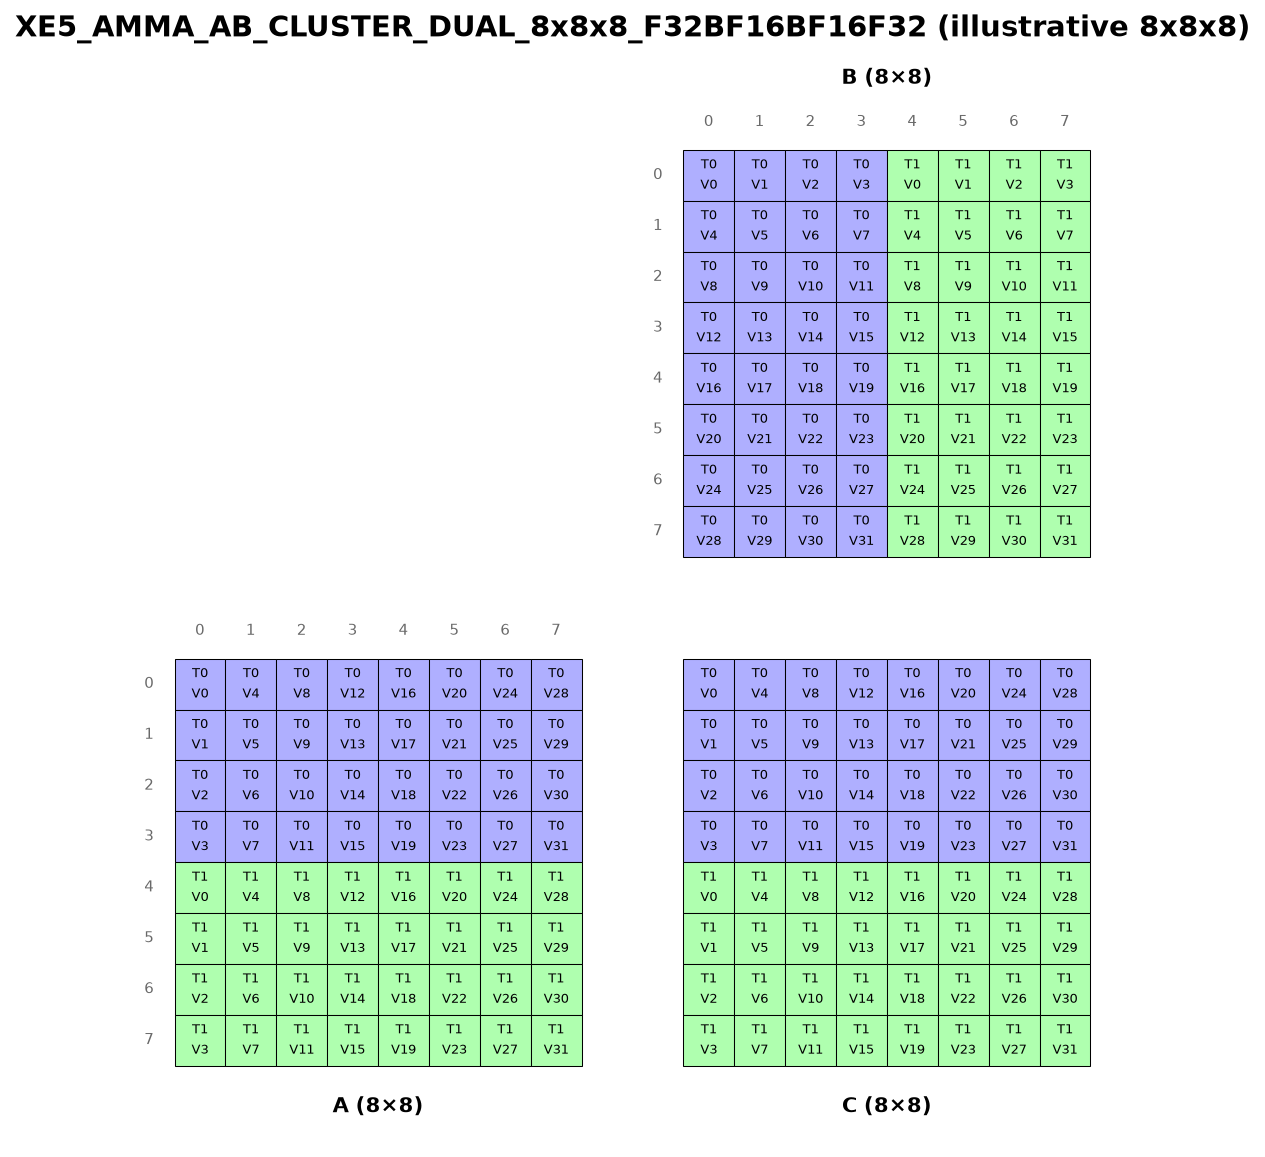

In [14]:
# Draw a small dual-group atom (8x8x8) so the lane-pair M/N split is legible.
from tensor_layouts.atoms_xe5 import make_xe5_amma_atom
dsmall = make_xe5_amma_atom("XE5_AMMA_AB_CLUSTER_DUAL", "amma.atmm.btmm (cluster, dual)",
                            "f32", "bf16", "bf16", "f32", 8, 8, 8, dual=True)
draw_mma_layout(dsmall.a_layout, dsmall.b_layout, dsmall.c_layout,
                tile_mnk=dsmall.shape_mnk, main_title=dsmall.name + " (illustrative 8x8x8)",
                thr_id_layout=dsmall.thr_id)


## 8. Full atom inventory

Everything emulated in this notebook, by family.  Block-scaled MX (including
Xe5 fp6 `e3m2`/`e2m3`), cluster/workgroup barrier scopes, and LARGE core
matrices are all included.


In [15]:
def show(title, atoms):
    print(f"\n=== {title} ({len(atoms)}) ===")
    for a in atoms:
        print("  ", a.name)

show("Xe  MMA (XE_DPAS_TT)", xe.MMA_ATOMS_XE)
show("Xe  Copy", xe.COPY_ATOMS_XE)
show("Xe4 MMA", xe4.MMA_ATOMS_XE4)
show("Xe4 Copy", xe4.COPY_ATOMS_XE4)
show("Xe5 MMA", xe5.MMA_ATOMS_XE5)
show("Xe5 Copy", xe5.COPY_ATOMS_XE5)



=== Xe  MMA (XE_DPAS_TT) (19) ===
   XE_DPAS_8x16x8_F32TF32TF32F32
   XE_DPAS_8x16x16_F32BF16BF16F32
   XE_DPAS_8x16x16_BF16BF16BF16F32
   XE_DPAS_8x16x16_F32BF16BF16BF16
   XE_DPAS_8x16x16_BF16BF16BF16BF16
   XE_DPAS_8x16x16_F32F16F16F32
   XE_DPAS_8x16x16_F32F16F16F16
   XE_DPAS_8x16x16_F16F16F16F32
   XE_DPAS_8x16x16_F16F16F16F16
   XE_DPAS_8x16x32_U32U8U8U32
   XE_DPAS_8x16x32_S32U8U8S32
   XE_DPAS_8x16x32_S32U8S8S32
   XE_DPAS_8x16x32_S32S8U8S32
   XE_DPAS_8x16x32_S32S8S8S32
   XE_DPAS_8x16x64_U32U4U4U32
   XE_DPAS_8x16x64_S32U4U4S32
   XE_DPAS_8x16x64_S32U4S4S32
   XE_DPAS_8x16x64_S32S4U4S32
   XE_DPAS_8x16x64_S32S4S4S32

=== Xe  Copy (11) ===
   XE_ATOMIC_F32
   XE_1D_LDSM_BF16
   XE_1D_STSM_BF16
   XE_1D_LOAD_GLOBAL_BF16
   XE_1D_LOAD_GLOBAL_F32
   XE_1D_STORE_GLOBAL_BF16
   XE_LOAD_2D_16b_16x16
   XE_LOAD_2D_32b_8x16
   XE_LOAD_2D_TRANSPOSE_32b_16x8
   XE_STORE_2D_32b_8x16
   XE_PREFETCH_2D_16b_16x16

=== Xe4 MMA (20) ===
   XE4_TMM_32x32x16_F32BF16BF16F32
   XE4_TMM_32x32x16

## 9. Real xe4 / xe5 example configurations

The atoms above are the building blocks; real kernels compose them over a **CTA
tile**.  This section mirrors the actual sycl-tla examples under
`examples/xe4/` — same tile shapes, dtypes and atom family — and shows how each
CTA tile decomposes into MMA-atom tiles staged through SLM.  (See the runnable
`examples/xe4_xe5_kernels.py`.)

| Example | Source | CTA tile M×N×K |
|---------|--------|----------------|
| XE4 GEMM (fp16)          | `xe4/gemm/gemm.cpp`               | 256×256×128 |
| XE4 Grouped GEMM         | `xe4/grouped_gemm/`               | 256×256×128 |
| XE4 Block-scaled (fp8+MX)| `xe4/gemm/gemm_blockscaled.cpp`   | 128×256×128 |
| XE5 GEMM (dual-group)    | projected from the xe4 template   | 256×256×128 |
| XE4 FMHA4 forward        | `xe4/fmha4/xe4_fmha_fwd.cpp`      | ⟨64,128,128,128⟩ |


In [16]:
import os, sys
sys.path.insert(0, os.path.abspath("."))       # notebook runs from examples/
sys.path.insert(0, os.path.abspath(".."))      # or from repo root
try:
    from xe4_xe5_kernels import GEMM_CONFIGS, FMHA_CONFIGS
except ModuleNotFoundError:
    from examples.xe4_xe5_kernels import GEMM_CONFIGS, FMHA_CONFIGS
GEMM_CONFIGS[0].describe()   # XE4 GEMM 256x256x128 fp16
GEMM_CONFIGS[3].describe();  # XE5 dual-group GEMM



XE4 GEMM (fp16, RowMajor)
  (from examples/xe4/gemm/gemm.cpp)
  CTA tile  M×N×K : 256 × 256 × 128   dtypes A=f16 B=f16
  MMA atom  M×N×K : 128 × 128 × 32   (XE4_AMMA_AB_128x128x32_F32F16F16F32)
  atom grid       : 2×2×4 = 16 atom invocations / CTA (4 accumulator tiles × 4 K-steps)


  SLM A tile      : ((2, 4, 4, 8), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=32768, bijective=True)


  SLM B tile      : ((2, 4, 4, 8), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=32768, bijective=True)



XE5 GEMM (dual-group, projected from xe4 template)
  (from examples/xe4/gemm/gemm.cpp + XE5 dual-group AMMA)
  CTA tile  M×N×K : 256 × 256 × 128   dtypes A=bf16 B=bf16  [dual-group]
  MMA atom  M×N×K : 128 × 128 × 32   (XE5_AMMA_AB_CLUSTER_DUAL_128x128x32_F32BF16BF16F32)
  atom grid       : 2×2×4 = 16 atom invocations / CTA (4 accumulator tiles × 4 K-steps)


  SLM A tile      : ((2, 4, 4, 8), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=32768, bijective=True)


  SLM B tile      : ((2, 4, 4, 8), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=32768, bijective=True)


### The XE4 GEMM accumulator grid

A 256×256×128 CTA tile with a 128×128×32 `XE4_AMMA` atom decomposes into a
**2×2 grid of accumulator tiles**, each accumulating over **4 K-steps** — 16
atom invocations per CTA.


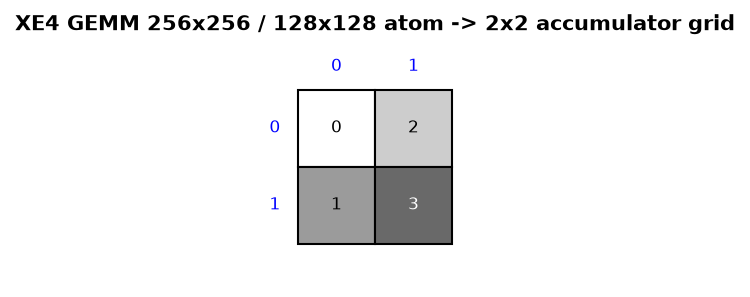

In [17]:
draw_layout(Layout((2, 2), (1, 2)),
            title="XE4 GEMM 256x256 / 128x128 atom -> 2x2 accumulator grid")


### FMHA4 forward — two GEMMs with a softmax bridge

`examples/xe4/fmha4/xe4_fmha_fwd.cpp` runs **S = Q·Kᵀ**, a row-wise
**softmax**, then **O = P·V**.  Q→A and K→B feed the first `TiledMmaQK` via
ADMA loads; the S→P bridge uses an **LDSM warp-row** copy so that row-mates land
in the same 32-lane warp for in-warp `fred.max` reductions (an Xe4-specific
mechanism); then P→A and V→B feed `TiledMmaPV`.


In [18]:
FMHA_CONFIGS[0].describe()   # XE4 FMHA4 forward, tile <64,128,128,128>



XE4 FMHA4 forward (fp16)
  (from examples/xe4/fmha4/xe4_fmha_fwd.cpp)
  TileShape <Qblk, Vdim, KVblk, QKdim> = (64, 128, 128, 128)
  dtypes: Q,K,V=f16  P=f16  accum=f32

  GEMM-1  S = Q · Kᵀ   (M×N×K = 64×128×128)
    Q -> A operand,  K -> B operand   via ADMA_Q / ADMA_K loads
      atom (64, 128, 32) -> grid 1×1×4 = 4 invocations


      SLM A ((2, 4, 4, 2), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=8192, bijective=True)


      SLM B ((2, 4, 4, 4), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=16384, bijective=True)



  softmax(S) -> P   (row-wise over N = 128 keys)
    LDSM warp-row load: XE4_LDSM_VS8_F16  ThrID=32 (row-mates co-resident for fred.max)
    S tile has 64 query rows; each reduced across 128 keys

  GEMM-2  O = P · V   (M×N×K = 64×128×128)
    P -> A operand,  V -> B operand   via ADMA_V load
      atom (64, 128, 32) -> grid 1×1×4 = 4 invocations


      SLM A ((2, 4, 4, 2), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=8192, bijective=True)


      SLM B ((2, 4, 4, 4), (16, 8)) : ((16, 128, 32, 4096), (1, 512))  (size=16384, bijective=True)


{'name': 'XE4 FMHA4 forward (fp16)',
 'qk': (64, 128, 128),
 'pv': (64, 128, 128)}

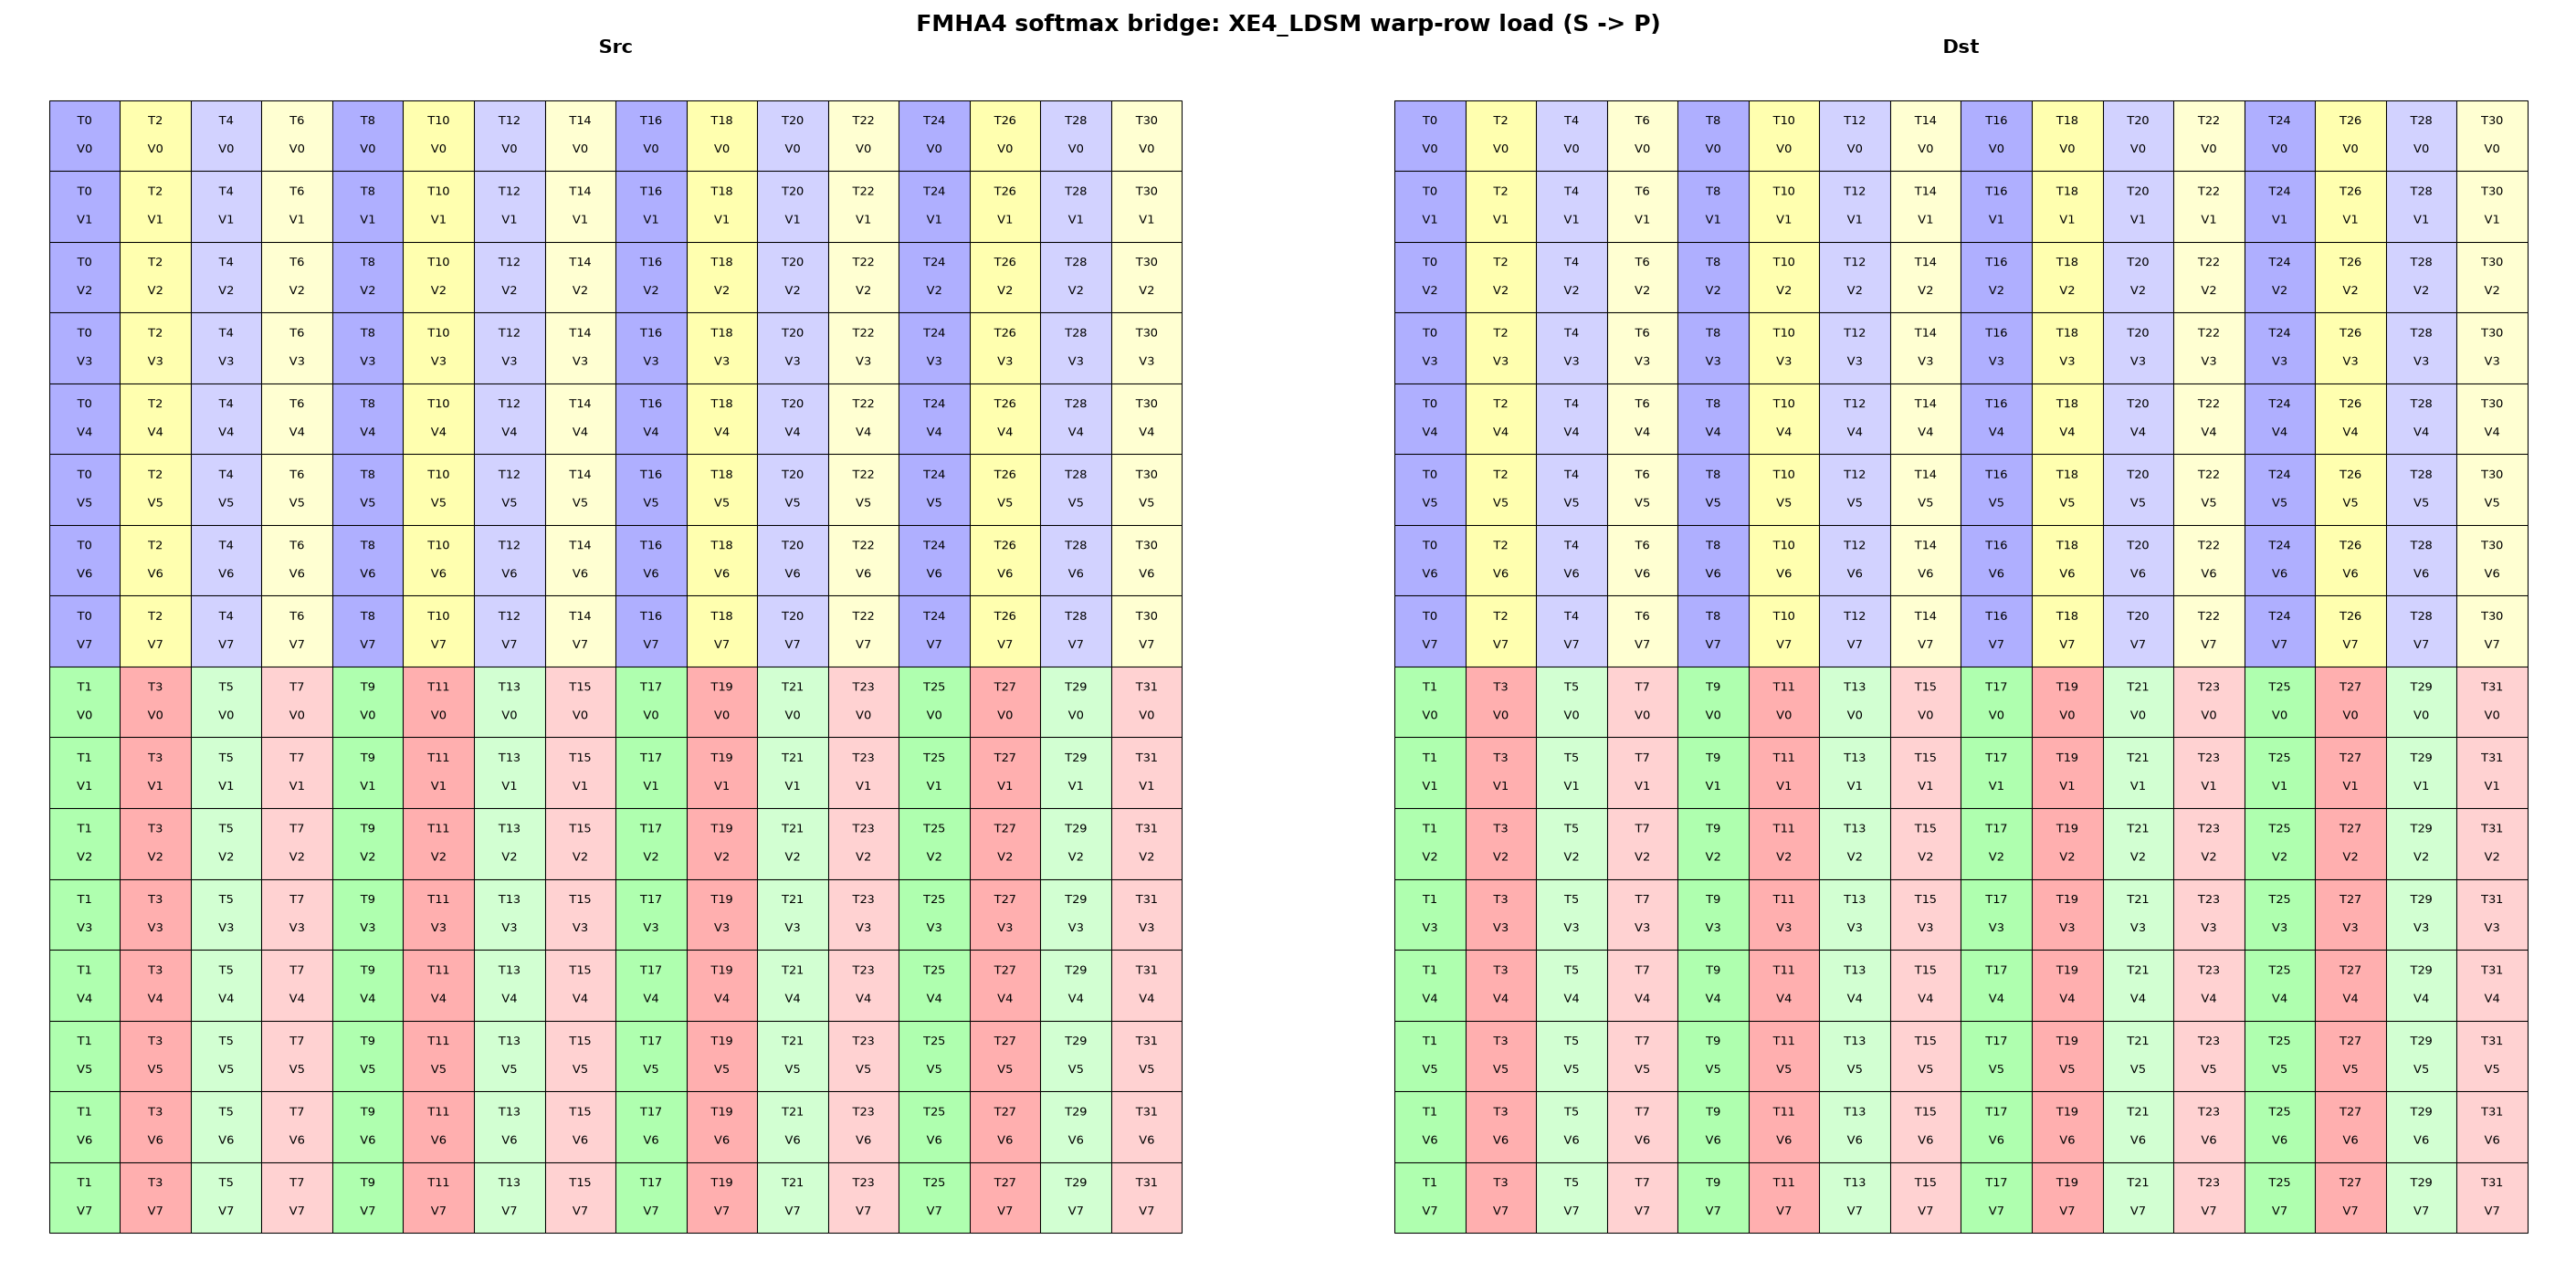

In [19]:
# The softmax bridge copy atom (SLM -> registers, warp-row property).
from tensor_layouts.atoms_xe4 import make_xe4_ldstm
draw_copy_atom(make_xe4_ldstm("LDSM", VS=8, s="f16"), element_bits=16,
               title="FMHA4 softmax bridge: XE4_LDSM warp-row load (S -> P)")
